## Importing the necessary libraries

In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import VotingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
import time
from thefuzz import process, fuzz


# Data preparation

## 1-Data Inspection

#### Load data

In [169]:
df_hit=pd.read_csv('homeintunisia_maison_vente.csv')

In [170]:
df_mub=pd.read_csv('mubawab_maison_vente.csv')

In [171]:
df_star=pd.read_csv('properstar_maison_acheter.csv')

In [172]:
df_remax=pd.read_csv('remax_maison_acheter.csv')

In [173]:
euro_to_dinar=3.38

#### Inspect data

In [174]:
df_hit.head(3)

,link,title,address,price,type,Référence,Pièces,Surface,Surface totale,Type de chauffage,...,Sous-sol 6 m²,Terrain 572 m²,Terrains 2032 m²,Terrains 1000 m²,Terrains 1291 m²,Terrains 1293 m²,Terrains 1667 m²,Terrains 8940 m²,Terrains 5160 m²,Appartement 109 m²
0,https://www.homeintunisia.com/fr/propri%C3%A9t...,À Vendre – Villa spacieuse à Khzema,Sousse Khezama,1 300 000 TND,Maison,85853297,6 pièces,350 m²,450 m²,"Radiateur, Climatisation",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.homeintunisia.com/fr/propri%C3%A9t...,Villa neuve à vendre Kantaoui côté mer,El Kantaoui,2 400 000 TND,Maison,85839722,12 pièces,494 m²,600 m²,Central,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.homeintunisia.com/fr/propri%C3%A9t...,🏰 VILLA COLONIALE PRESTIGE AVEC PISCINE – LA M...,La Marsa,1 730 400 TND,Maison,85836272,9 pièces,600 m²,600 m²,"Radiateur, Central",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [175]:
df_mub.head(3)

,link,title,address,price,m²,Chambres,Salles de bains,Type de bien,Standing,État,...,Réfrigérateur,Machine à laver,Orientation,Salle de bain,Vue sur mer,Meublé,Pièce,Chambre,Surface habitable,Surface extérieure
0,https://www.mubawab.tn/fr/pa/7940166/splendide...,Splendide villa à vendre à Gammarth. Superfici...,Gammarth à La Marsa,856 000 TND,405.0,4.0,5.0,Villa,Haut standing,En cours de construction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.mubawab.tn/fr/pa/7845699/duplex-de...,Duplex de luxe à vendre,Les Jardins de Carthage à Le Kram,Prix à consulter,265.0,3.0,3.0,Villa,Haut standing,En cours de construction,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.mubawab.tn/fr/a/8022200/villa-seba...,Villa sebastian,Hammamet Sud à Hammamet,892 000 TND,485.0,4.0,4.0,Villa,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [176]:
df_star.head(3)

,link,class,title,description,address,price,latitude,longitude,Pièces,Etages,...,Ascenseur,Tennis,Centre de remise en forme,Salle à manger,Hammam,Cave à vin,Lave-vaisselle,Piscine extérieure,Studio de yoga,Suites d'hôtes
0,https://www.properstar.fr/annonce/103912219,maison,"Maison à vendre à Djerba Midoun, Tunisie",Villa • 7 pce(s) • 4 chambres • 3 sdb • 402 m²...,Djerba Midoun,117 049 €,33.775472,10.958095,7.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.properstar.fr/annonce/101542965,maison,"Maison à vendre à Hammamet, Tunisie",Maison • 5 pce(s) • 4 chambres • 3 sdb • 280 m...,Hammamet,324 994 €,36.407257,10.622471,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.properstar.fr/annonce/106123620,maison,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [177]:
df_remax.head(3)

,link,title,prix,payment_method,latitude,longitude,address,statut_marche,Nombre de pièces,Nombre de chambres,...,Équipements inclus,Partiellement meublé,Est,Montagnes,Vue sur montagne,Buanderie,Pieds dans l'eau,Wooden Window Frames,Baroque,Style colonial
0,https://www.remax.com.tn/fr-tn/biens/villa/ven...,Villa - Vente - Ben Arous Ben Arous Tunisie,"680,000 TND",NaN,36.743500,10.231976,Ben Arous - Ben Arous - Tunisie,Nouveau sur le marché,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,https://www.remax.com.tn/fr-tn/biens/villa/ven...,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,https://www.remax.com.tn/fr-tn/biens/villa/ven...,Villa - Vente - Sidi El Béchir Tunis Tunisie,Nous consulter,NaN,36.792686,10.179430,Sidi El Béchir - Tunis - Tunisie,A renover,15.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


##### shape of the data (number of rows, number of columns)

In [178]:
df_hit.shape

(165, 408)

In [179]:
df_mub.shape

(4118, 49)

In [180]:
df_star.shape

(526, 57)

In [181]:
df_remax.shape

(129, 119)

##### column names

In [182]:
df_hit.columns

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       ...
       'Sous-sol 6 m²', 'Terrain 572 m²', 'Terrains 2032 m²',
       'Terrains 1000 m²', 'Terrains 1291 m²', 'Terrains 1293 m²',
       'Terrains 1667 m²', 'Terrains 8940 m²', 'Terrains 5160 m²',
       'Appartement 109 m²'],
      dtype='object', length=408)

In [183]:
df_mub.columns

Index(['link', 'title', 'address', 'price', 'm²', 'Chambres',
       'Salles de bains', 'Type de bien', 'Standing', 'État', 'latitude',
       'longitude', 'Pièces', 'Jardin', 'Terrasse', 'Piscine',
       'Antenne parabolique', 'Climatisation', 'Chauffage central', 'Sécurité',
       'Double vitrage', 'Porte blindée', 'Cuisine équipée', 'Four', 'Etat',
       'Etat du bien', 'Type du sol', 'Livraison:', 'Garage', 'Entre-seul',
       'Salon européen', 'Nombre d'étages', 'Surface de la parcelle',
       'Vue sur les montagnes', 'Micro-ondes', 'Cheminée', 'Ascenseur',
       'Concierge', 'Chambre rangement', 'Réfrigérateur', 'Machine à laver',
       'Orientation', 'Salle de bain', 'Vue sur mer', 'Meublé', 'Pièce',
       'Chambre', 'Surface habitable', 'Surface extérieure'],
      dtype='object')

In [184]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Habitable',
       'Terrain', 'Total', 'Piscine', 'Terrasse', 'Type',
       'Année de construction', 'Places de parc intérieures', 'Jardin',
       'Balcon', 'Condition', 'Chauffage', 'Climatisation', 'Meublé',
       'Parking', 'Standing', 'Eau chaude', 'Déchets des eaux usées', 'Alarme',
       'Année de rénovation', 'Interphone', 'Jacuzzi',
       'Recharge de véhicules électriques', 'Télévision par satellite',
       'Internet', 'Machine à laver', 'Sauna', 'Barbecue', 'Concierge 24/7',
       'Sécurité', 'Garage', 'Piscine intérieure', 'Ascenseur', 'Tennis',
       'Centre de remise en forme', 'Salle à manger', 'Hammam', 'Cave à vin',
       'Lave-vaisselle', 'Piscine extérieure', 'Studio de yoga',
       'Suites d'hôtes'],
      dtype='object')

#### matching columns

In [185]:
cols_mub=['price','address', 'm²', 'Surface habitable','Pièces','Salles de bains','Salle de bain', 'Terrasse',
          'Meublé','Climatisation','Chauffage central', 'Sécurité',"Nombre d'étages",
          'latitude', 'longitude', 'Chambres', 'Garage', 'Jardin', 'Piscine']
cols_renamed = {
    'm²': 'total_area',
    'Surface habitable':'living_area',
    'Pièces': 'rooms',
    'Chambres': 'bedrooms',
    'Salles de bains': 'bathrooms',
    'Salle de bain': 'bathroom',
    'Jardin': 'garden',
    'Garage': 'garage',
    'Piscine': 'pool',
    'Chauffage central': 'heating',
    'latitude': 'latitude',
    'longitude': 'longitude',
    'Terrasse': 'terrace',
    'Climatisation': 'air_conditioning',
    'Surface de la parcelle': 'total_area',  #
    'Meublé': 'furnished',
    "Sécurité":"security",
    "Nombre d'étages":"floor"
}
# Assuming df is your DataFrame
df_mub = df_mub[cols_mub].rename(columns=cols_renamed)
df_mub.columns

Index(['price', 'address', 'total_area', 'living_area', 'rooms', 'bathrooms',
       'bathroom', 'terrace', 'furnished', 'air_conditioning', 'heating',
       'security', 'floor', 'latitude', 'longitude', 'bedrooms', 'garage',
       'garden', 'pool'],
      dtype='object')

In [186]:
hit_cols=df_hit.columns
hit_cols[0:20]

Index(['link', 'title', 'address', 'price', 'type', 'Référence', 'Pièces',
       'Surface', 'Surface totale', 'Type de chauffage',
       'Énergie de chauffage', 'Moyen de chauffage', 'Type d'eau chaude',
       'Moyen d'eau chaude', 'Eaux usées', 'État', 'Étage', 'Exposition',
       'Vue', 'Salon'],
      dtype='object')

In [187]:
cols_hit=['price','Pièces','address','Surface totale','Surface','Salles de bains','Salle de bains','Étage',
    'Type de chauffage','Piscine','latitude','longitude','Air conditionné','Meublé',
    'Piscine en copropriété','Terrasse','Alarme','Vidéo surveillance','Garage','Jardin',
    'Chambres']
df_hit=df_hit[cols_hit]
# Using pandas rename method directly
df_hit = df_hit.rename(columns={
    'Pièces': 'rooms',
    'Surface totale': 'total_area',
    'Surface':'living_area',
    'Étage': 'floor_number',
    'Salon': 'living_room',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine en copropriété': 'shared_pool',
    'Salles de bains':'bathrooms',
    'Salle de bains':'bathroom',
    'Type de chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'alarm',
    'Vidéo surveillance':'video_surveillance',
    'Garage':'garage',
    'Jardin':'garden'
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'living_area', 'bathrooms',
       'bathroom', 'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms'],
      dtype='object')

In [188]:
df_star.columns

Index(['link', 'class', 'title', 'description', 'address', 'price', 'latitude',
       'longitude', 'Pièces', 'Etages', 'Chambres', 'Salles de bains',
       'Toilettes', 'Appartements', 'Places de parc extérieur', 'Habitable',
       'Terrain', 'Total', 'Piscine', 'Terrasse', 'Type',
       'Année de construction', 'Places de parc intérieures', 'Jardin',
       'Balcon', 'Condition', 'Chauffage', 'Climatisation', 'Meublé',
       'Parking', 'Standing', 'Eau chaude', 'Déchets des eaux usées', 'Alarme',
       'Année de rénovation', 'Interphone', 'Jacuzzi',
       'Recharge de véhicules électriques', 'Télévision par satellite',
       'Internet', 'Machine à laver', 'Sauna', 'Barbecue', 'Concierge 24/7',
       'Sécurité', 'Garage', 'Piscine intérieure', 'Ascenseur', 'Tennis',
       'Centre de remise en forme', 'Salle à manger', 'Hammam', 'Cave à vin',
       'Lave-vaisselle', 'Piscine extérieure', 'Studio de yoga',
       'Suites d'hôtes'],
      dtype='object')

In [189]:
cols_star=['price','address','latitude','longitude','Pièces','Etages','Chambres','Salles de bains',
        'Total','Piscine', 'Terrasse','Jardin','Chauffage', 'Climatisation','Meublé',
        'Alarme','Garage','Piscine intérieure','Habitable']
df_star=df_star[cols_star]
# Using pandas rename method directly
df_star = df_star.rename(columns={
    'Pièces': 'rooms',
    'Total': 'total_area',
    'Habitable':'living_area',
    'Étage': 'floor_number',
    'Chambres': 'bedrooms',
    'Piscine': 'pool',
    'Climatisation': 'air_conditioning',
    'Meublé': 'furnished',
    'Piscine intérieure': 'indoor_pool',
    'Salles de bains':'bathrooms',
    'Chauffage':'heating',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    'Etages':'floor'
})
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'living_area', 'bathrooms',
       'bathroom', 'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'shared_pool', 'terrace', 'alarm',
       'video_surveillance', 'garage', 'garden', 'bedrooms'],
      dtype='object')

In [190]:
remax_cols=df_remax.columns
remax_cols[0:30]

Index(['link', 'title', 'prix', 'payment_method', 'latitude', 'longitude',
       'address', 'statut_marche', 'Nombre de pièces', 'Nombre de chambres',
       'Nombre salles de bain', 'm²', 'Surface Terrain (m²)',
       'Surface constructible (m²)', 'Places de parking', 'Nombre d'étages',
       'Etage', 'Nombre de WC', 'Balcon', 'Garage', 'Jardin', 'Terrasse',
       'Terrasse sur le toit', 'Travaux à prévoir', 'Cuisine',
       'Cuisine/Salle à manger', 'Hall d'entrée', 'Rénovation à prévoir',
       'Habitation', 'Vue dégagée'],
      dtype='object')

In [191]:
cols_remax=['prix','latitude','longitude','Nombre de pièces','Nombre de chambres','Nombre salles de bain',
            'm²',"Nombre d'étages", 'Garage', 'Jardin', 'Terrasse','Air Conditionné',
            'Piscine','Meublé','Système de sécurité', 'Système de surveillance','Camera de sécurité',
            'Chauffage Central','Chauffage au sol','Surface Terrain (m²)']
df_remax=df_remax[cols_remax]
# Using pandas rename method directly
df_remax = df_remax.rename(columns={
    'prix':'price',
    'Nombre de pièces': 'rooms',
    'Surface Terrain (m²)':'total_area',
    'm²': 'living_area',
    "Nombre d'étages": 'floor',
    'Nombre de chambres': 'bedrooms',
    'Piscine': 'pool',
    'Air Conditionné': 'air_conditioning',
    'Meublé': 'furnished',
    'Nombre salles de bain':'bathrooms',
    'Terrasse':'terrace',
    'Alarme':'security',
    'Garage':'garage',
    'Jardin':'garden',
    'Etages':'floor'
})
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'living_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'Chauffage Central',
       'Chauffage au sol', 'total_area'],
      dtype='object')

## 2- Data Cleaning

### a-standardizing Formats

#### -df_hit

In [192]:
df_hit["price"].sample(5)

135    3 700 000 TND
27     1 390 500 TND
112      927 000 TND
139    2 700 000 TND
51     1 650 000 TND
Name: price, dtype: object

In [193]:
print(df_hit.shape)
df_hit=df_hit[df_hit['price']!="Prix sur demande"]
print(df_hit.shape)

(165, 21)
(156, 21)


In [194]:
# Filter rows where the price column contains the word "Moin /jour / An"
mois_df = df_hit[df_hit['price'].astype(str).str.contains('Mois', case=False)]
jour_df=df_hit[df_hit['price'].astype(str).str.contains('Jour', case=False)]
semaine_df=df_hit[df_hit['price'].astype(str).str.contains('Semaine', case=False)]
year_df=df_hit[df_hit['price'].astype(str).str.contains('An', case=False)]
print(mois_df.shape)
print(jour_df.shape)
print(semaine_df.shape)

(0, 21)
(0, 21)
(0, 21)


In [195]:
print(df_hit.shape)
df_hit = df_hit[~df_hit['price'].astype(str).str.contains('Mois|Jour|Semaine|An', case=False)]
print(df_hit.shape)

(156, 21)
(156, 21)


In [196]:
# Removing the word TND and changing data type to float
df_hit['price'] = df_hit['price'].str.replace('TND', '')
# Remove all types of spaces (including non-breaking spaces and other whitespace)
df_hit['price'] = df_hit['price'].str.replace(r'\s+', '', regex=True)
# Now convert to float
df_hit['price'] = df_hit['price'].astype(float)

In [197]:
df_hit['rooms'].value_counts()

rooms
5 pièces     23
4 pièces     21
6 pièces     20
10 pièces    14
3 pièces     13
7 pièces     12
8 pièces     12
9 pièces      6
11 pièces     2
13 pièces     2
15 pièces     2
1 pièce       1
12 pièces     1
14 pièces     1
19 pièces     1
2 pièces      1
20 pièces     1
16 pièces     1
Name: count, dtype: int64

In [198]:
df_hit['rooms']=df_hit['rooms'].str.replace(' pièces','')
df_hit['rooms']=df_hit['rooms'].str.replace(' pièce','')
df_hit['rooms']=df_hit['rooms'].astype(float)
df_hit['rooms'].value_counts()

rooms
5.0     23
4.0     21
6.0     20
10.0    14
3.0     13
7.0     12
8.0     12
9.0      6
11.0     2
13.0     2
15.0     2
1.0      1
12.0     1
14.0     1
19.0     1
2.0      1
20.0     1
16.0     1
Name: count, dtype: int64

In [199]:
df_hit['total_area'].value_counts().head(3)

total_area
450 m²    6
600 m²    6
300 m²    5
Name: count, dtype: int64

In [200]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['total_area','living_area']  # List of size-related columns
for col in columns_to_transform:
    df_hit = clean_size_column(df_hit, col)
# Check the cleaned columns
df_hit[columns_to_transform].sample(5)


,total_area,living_area
121,1400.0,325.0
81,700.0,600.0
76,NaN,700.0
51,1000.0,500.0
152,688.0,458.0


In [201]:
df_hit['pool'] = df_hit[['pool', 'shared_pool']].max(axis=1)
df_hit.drop(columns=['shared_pool'],inplace=True)

In [202]:
df_hit['bathrooms'] = df_hit[['bathroom', 'bathrooms']].max(axis=1)
df_hit.drop(columns=['bathroom'],inplace=True)

In [203]:
df_hit['security']=0
df_hit['security']=df_hit[['video_surveillance', 'alarm']].max(axis=1)
df_hit=df_hit.drop(columns=['video_surveillance', 'alarm'],axis=1)
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'living_area', 'bathrooms',
       'floor_number', 'heating', 'pool', 'latitude', 'longitude',
       'air_conditioning', 'furnished', 'terrace', 'garage', 'garden',
       'bedrooms', 'security'],
      dtype='object')

In [204]:
# Set to 1 for properties with any type of heating
df_hit["heating"]=df_hit["heating"].fillna(0)
df_hit["heating"]=df_hit["heating"].apply(lambda x: 0 if x=="Sans chauffage" else 1)
print(df_hit['heating'].value_counts())

heating
1    154
0      2
Name: count, dtype: int64


In [205]:
df_hit['floor_number'].value_counts()

floor_number
Rez-de-chaussée               45
Plain-pied                    14
Rez-de-chaussée / 2 étages    12
Rez-de-chaussée / 1 étage     11
1er                            4
Plain-pied / 1 étage           3
Rez-de-jardin / 2 étages       2
Plain-pied / 3 étages          2
Rez-de-chaussée / 3 étages     2
1er étage / 1                  1
Plain-pied / 2 étages          1
Surélevé                       1
Rez-de-jardin                  1
2ème                           1
6ème                           1
2ème étage / 2                 1
Name: count, dtype: int64

In [206]:
# create a new column for the extracted floor number
df_hit['floor_numeric'] = None
# Function to extract floor number
def extract_floor_number(floor_str):
    if not isinstance(floor_str, str):
        return None
        
    # Handle special cases
    if 'Rez-de-chaussée' in floor_str or 'Rez-de-jardin' in floor_str:
        return 0
    if 'Plain-pied' in floor_str:
        return 0
    if 'Surélevé' in floor_str:
        return 0.5
        
    # Extract floor number from strings like "1er", "2ème", etc.
    """
    ^ :This character is responsible for matching the start of the string. It ensures that the
     pattern only matches digits that appear at the beginning of the text, not somewhere in the 
     middle or end.
    \d+ : /d matches any signe digit like 1 2 3 ... , + means one or more like 11 12 10 ...
    The parentheses ()reate a capture group. They're responsible for isolating the part of the 
        match that you want to extract.
    """
    match = re.search(r'^(\d+)', floor_str)
    if match:
        return int(match.group(1))        
    return None

# Apply the function to the floor_number column
df_hit['floor_numeric'] = df_hit['floor_number'].apply(extract_floor_number)
# Convert to float
df_hit['floor_numeric'] = df_hit['floor_numeric'].astype(float)
# Check the results
print(df_hit['floor_numeric'].value_counts())

floor_numeric
0.0    93
1.0     5
2.0     2
0.5     1
6.0     1
Name: count, dtype: int64


In [207]:
df_hit=df_hit.drop(columns=['floor_number'],axis=1)
df_hit=df_hit.rename(columns={'floor_numeric':'floor'})

In [208]:
df_hit.columns

Index(['price', 'rooms', 'address', 'total_area', 'living_area', 'bathrooms',
       'heating', 'pool', 'latitude', 'longitude', 'air_conditioning',
       'furnished', 'terrace', 'garage', 'garden', 'bedrooms', 'security',
       'floor'],
      dtype='object')

#### df_mub

In [209]:
print(df_mub.shape)
df_mub=df_mub[df_mub['price']!="Prix à consulter"]
print(df_mub.shape)

(4118, 19)
(3290, 19)


In [210]:
df_mub['price'].head(10)

0       856 000 TND
2       892 000 TND
4     1 250 000 TND
5     1 150 000 TND
7     2 200 000 TND
8       190 000 TND
9       980 000 TND
10      200 000 TND
12      945 000 TND
13    3 000 000 TND
Name: price, dtype: object

In [211]:
for idx, row in df_mub.iterrows():
    price_ch = df_mub.loc[idx, 'price']
    position_tnd = price_ch.find('TND')
    position_eur=price_ch.find('EUR')
    if position_tnd !=-1:
        price = price_ch.replace('TND','') 
        price=price.replace(' ','')
        price=float(price)
    elif position_eur!=-1:
        price = price_ch.replace('EUR','')
        price=price.replace(' ','')
        price=float(price) * euro_to_dinar
    df_mub.loc[idx, "price"] = price
df_mub['price']=df_mub['price'].astype(float)

In [212]:
df_mub['living_area'].value_counts()

living_area
530 m²    1
302 m²    1
Name: count, dtype: int64

In [213]:
print(df_mub.shape)
df_mub=clean_size_column(df_mub, 'living_area')
print(df_mub.shape)


(3290, 19)
(3290, 19)


In [214]:
df_mub['total_area'].sample(3)

2032    285.0
3258    140.0
2346    172.0
Name: total_area, dtype: float64

In [215]:
df_mub['bathrooms'] = df_mub[['bathroom', 'bathrooms']].max(axis=1)
df_mub.drop(columns=['bathroom'],inplace=True)

In [216]:
df_mub['floor'].value_counts()

floor
2.0    264
1.0    206
3.0     72
4.0      9
Name: count, dtype: int64

#### Df star

In [217]:
df_star["total_area"].sample(2)

56       NaN
64    353 m²
Name: total_area, dtype: object

In [218]:
df_star["living_area"].sample(2)

230    550 m²
73     347 m²
Name: living_area, dtype: object

In [219]:
def clean_size_column(df_func, col):
    """
    Cleans a size-related column by:
    1. Removing 'm²' and any non-breaking spaces.
    2. Stripping leading/trailing spaces.
    3. Converting cleaned values to numeric (float).
    4. Handling missing or invalid values gracefully.
    """
    df_func[col] = df_func[col].astype(str)  # Convert all to string to prevent errors
    df_func[col] = df_func[col].str.replace('m²', '', regex=False)  # Remove 'm²'
    df_func[col] = df_func[col].str.replace('\u202f', '', regex=False)  # Remove non-breaking spaces
    df_func[col] = df_func[col].str.replace(' ', '', regex=False)  # Remove normal spaces
    df_func[col] = df_func[col].str.strip()  # Strip leading/trailing spaces
    df_func[col] = pd.to_numeric(df_func[col], errors='coerce')  # Convert to float, setting errors to NaN
    return df_func
# Example usage
columns_to_transform = ['total_area','living_area']
for col in columns_to_transform:
    df_star = clean_size_column(df_star, col)
# Check the cleaned columns
df_star[columns_to_transform].sample(5)


,total_area,living_area
87,157.0,157.0
209,105.0,81.0
379,120.0,100.0
224,NaN,NaN
308,7029.0,7029.0


In [220]:
df_star['price'].head(10)

0    117 049 €
1    324 994 €
2          NaN
3          NaN
4          NaN
5          NaN
6    331 542 €
7    453 566 €
8    702 296 €
9    248 730 €
Name: price, dtype: object

In [221]:
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace('€','') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace('\u202f', '') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: str(x).replace(' ','') if isinstance(x, str) else x)
df_star['price'] = df_star['price'].apply(lambda x: x.strip() if isinstance(x, str) else x)
df_star['price'] = pd.to_numeric(df_star['price'], errors='coerce')
df_star['price']=df_star['price'].apply(lambda x : x* euro_to_dinar)
df_star['price'].head(10)


0     395625.62
1    1098479.72
2           NaN
3           NaN
4           NaN
5           NaN
6    1120611.96
7    1533053.08
8    2373760.48
9     840707.40
Name: price, dtype: float64

In [222]:
df_star["garden"].value_counts().head(5)

garden
1         11
400 m²     1
216 m²     1
270 m²     1
612 m²     1
Name: count, dtype: int64

In [223]:
df_star["heating"].value_counts().head(5)


heating
Chauffage central, Individuel, Gaz           83
Radiateur, Individuel, Gaz                   19
Gaz                                          18
Radiateur, Individuel, Electrique            14
Chauffage central, Individuel, Electrique     9
Name: count, dtype: int64

In [224]:
def handle_data(df_func,col):
    """
    This function is used to transform the data to binary:
    1. If the value is not 0, then the value is 1.
    2. If the value is 0 or NaN, then the value is 0.
    """
    df_func[col].fillna(0,inplace=True)
    df_func[col] = df_func[col].apply(lambda x: 1 if x != 0.0 else 0)
    return df_func
cols_transform_one=['heating','garden']
for col in cols_transform_one:
    df_star=handle_data(df_star,col)

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3694022162.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_func[col].fillna(0,inplace=True)


In [225]:
df_star['pool'] = df_star[['pool', 'indoor_pool']].max(axis=1)
df_star.drop(columns=['indoor_pool'],inplace=True)

#### Df remax

In [226]:
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'living_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'Chauffage Central',
       'Chauffage au sol', 'total_area'],
      dtype='object')

In [227]:
df_remax['heating']=0
df_remax['heating'] = df_remax[['Chauffage au sol','Chauffage Central']].max(axis=1)
df_remax.drop(columns=['Chauffage au sol','Chauffage Central'],inplace=True)
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'living_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'Système de sécurité',
       'Système de surveillance', 'Camera de sécurité', 'total_area',
       'heating'],
      dtype='object')

In [228]:
df_remax['security']=0
df_remax['security'] = df_remax[['Système de sécurité','Système de surveillance', 'Camera de sécurité']].max(axis=1)
df_remax.drop(columns=['Système de sécurité','Système de surveillance', 'Camera de sécurité'],inplace=True)
df_remax.columns

Index(['price', 'latitude', 'longitude', 'rooms', 'bedrooms', 'bathrooms',
       'living_area', 'floor', 'garage', 'garden', 'terrace',
       'air_conditioning', 'pool', 'furnished', 'total_area', 'heating',
       'security'],
      dtype='object')

In [229]:
df_remax=df_remax[df_remax['price']!='Nous consulter']
df_remax['price']=df_remax['price'].str.replace(' TND','')
df_remax['price']=df_remax['price'].str.replace(',','')
df_remax['price']=df_remax['price'].astype(float)

In [230]:
df_remax['total_area'].value_counts().head(5)

total_area
581      5
740      5
480      5
790      5
1,100    4
Name: count, dtype: int64

In [231]:
df_remax['living_area'].value_counts().head(5)

living_area
568      5
1,651    5
700      5
625      5
412      5
Name: count, dtype: int64

In [232]:
df_remax['total_area']=df_remax['total_area'].str.replace(',','')
df_remax['total_area']=df_remax['total_area'].astype(float)
df_remax['living_area']=df_remax['living_area'].str.replace(',','')
df_remax['living_area']=df_remax['living_area'].astype(float)

In [233]:
df_remax['floor'].value_counts()

floor
1.0    22
2.0    13
3.0     5
Name: count, dtype: int64

In [234]:
df_remax['floor'].value_counts()

floor
1.0    22
2.0    13
3.0     5
Name: count, dtype: int64

In [235]:
df_remax['terrace'].value_counts()

terrace
1.0    60
Name: count, dtype: int64

#### Combine dataframes

In [236]:
df=pd.concat([df_mub,df_hit,df_star,df_remax])
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4081 entries, 0 to 128
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             4016 non-null   float64
 1   address           3936 non-null   object 
 2   total_area        3788 non-null   float64
 3   living_area       628 non-null    float64
 4   rooms             3345 non-null   float64
 5   bathrooms         3249 non-null   float64
 6   terrace           2612 non-null   float64
 7   furnished         531 non-null    float64
 8   air_conditioning  2005 non-null   float64
 9   heating           2200 non-null   float64
 10  security          1118 non-null   float64
 11  floor             891 non-null    float64
 12  latitude          3990 non-null   float64
 13  longitude         3990 non-null   float64
 14  bedrooms          3294 non-null   float64
 15  garage            1964 non-null   float64
 16  garden            2914 non-null   float64
 17  p

In [237]:
df.shape

(4081, 18)

### b-handle missing values

#### Droping columns with high missing values 

In [238]:
df.isna().sum().sort_values(ascending=False)

furnished           3550
living_area         3453
floor               3190
security            2963
pool                2510
garage              2117
air_conditioning    2076
heating             1881
terrace             1469
garden              1167
bathrooms            832
bedrooms             787
rooms                736
total_area           293
address              145
latitude              91
longitude             91
price                 65
dtype: int64

pool/elevator/air_conditioning/furnished/heating NaN values means 0

In [239]:
percentage_missing=df.isnull().sum()*100/len(df)
percentage_missing.sort_values(ascending=False)

furnished           86.988483
living_area         84.611615
floor               78.167116
security            72.604754
pool                61.504533
garage              51.874541
air_conditioning    50.869885
heating             46.091644
terrace             35.996079
garden              28.595932
bathrooms           20.387160
bedrooms            19.284489
rooms               18.034795
total_area           7.179613
address              3.553051
latitude             2.229846
longitude            2.229846
price                1.592747
dtype: float64

#### Replace missing values with mean,mode,median,0 or 1
mode => categorical distribution

median => skewed distribution

mean => normal distribution

0/1 => when we know that the value is normally 1 or 0

In [240]:
df.columns

Index(['price', 'address', 'total_area', 'living_area', 'rooms', 'bathrooms',
       'terrace', 'furnished', 'air_conditioning', 'heating', 'security',
       'floor', 'latitude', 'longitude', 'bedrooms', 'garage', 'garden',
       'pool'],
      dtype='object')

In [241]:
df_clean=df.copy()

In [242]:
columns_with_zeros=['pool','garden','garage','security','heating','terrace',
                    'air_conditioning','furnished']
for col in columns_with_zeros:
    df_clean[col]=df_clean[col].fillna(0)
columns_with_one=['bathrooms']
for col in columns_with_one:
    df_clean[col]=df_clean[col].fillna(1)

In [243]:
percentage_missing=df_clean.isnull().sum()*100/len(df_clean)
percentage_missing.sort_values(ascending=False)

living_area         84.611615
floor               78.167116
bedrooms            19.284489
rooms               18.034795
total_area           7.179613
address              3.553051
longitude            2.229846
latitude             2.229846
price                1.592747
garden               0.000000
garage               0.000000
heating              0.000000
security             0.000000
air_conditioning     0.000000
furnished            0.000000
terrace              0.000000
bathrooms            0.000000
pool                 0.000000
dtype: float64

In [244]:
mode_columns=["rooms","bedrooms"]
for col in mode_columns:
    df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\2566872868.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


In [245]:
# Fill missing values
df_clean['total_area'] = df_clean['total_area'].fillna(df_clean['living_area'])
df_clean=df_clean.drop(columns=['living_area'],axis=1)
df_clean.isna().sum().sort_values(ascending=False)

floor               3190
total_area           161
address              145
longitude             91
latitude              91
price                 65
garden                 0
garage                 0
bedrooms               0
heating                0
security               0
air_conditioning       0
furnished              0
terrace                0
bathrooms              0
rooms                  0
pool                   0
dtype: int64

In [246]:
def plot_distribution(data,title,xlabel):
    plt.figure(figsize=(10, 6))
    sns.histplot(data, kde=True)  # kde=True will add a kernel density estimate curve to visualize distribution smoothly
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Frequency')
    plt.show()

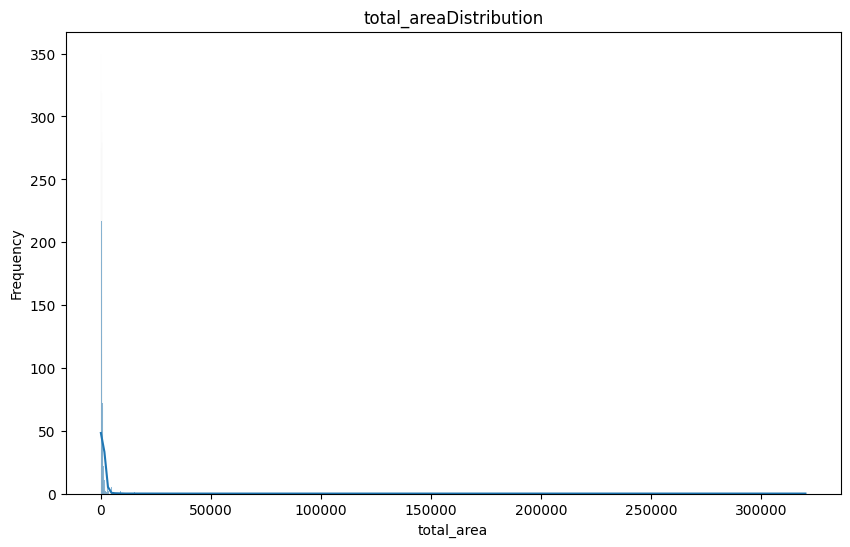

In [247]:
for col in ['total_area']:
    plot_distribution(df_clean[col],col + 'Distribution',col)

In [248]:
df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\2492172101.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['total_area'].fillna(df_clean['total_area'].median(), inplace=True)


#### address column

In [249]:
df_missing=df_clean[df_clean['address'].isnull()]
df_full=df_clean[df_clean['address'].notna()]
print(len(df_missing))

145


In [250]:
# Initialize the geocoder with rate limiting
geolocator = Nominatim(user_agent="tunisia_property_analysis")
geocode = RateLimiter(geolocator.reverse, min_delay_seconds=1)
# Function to extract location info from coordinates
def get_location_info(lat, lon):
    try:
        location = geocode((lat, lon), language='fr')
        if location and location.raw.get('address'):
            address = location.raw['address']
            municipality = address.get('municipality') or address.get('city') or address.get('town') or address.get('village') or address.get('suburb')
            return municipality
        return None
    except Exception as e:
        time.sleep(2)
        return None
# Create a copy of df_missing
df_filled = df_missing.copy()
# Process in batches
batch_size = 10
total = len(df_missing)
municipalities = []

for i in range(0, total, batch_size):
    batch = df_missing.iloc[i:min(i + batch_size, total)]
    for _, row in batch.iterrows():
        municipality= get_location_info(row['latitude'], row['longitude'])
        municipalities.append(municipality)
    time.sleep(1)
df_filled['address'] = municipalities

In [251]:
df_clean = pd.concat([df_full, df_filled])
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4081 entries, 0 to 128
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   price             4016 non-null   float64
 1   address           3983 non-null   object 
 2   total_area        4081 non-null   float64
 3   rooms             4081 non-null   float64
 4   bathrooms         4081 non-null   float64
 5   terrace           4081 non-null   float64
 6   furnished         4081 non-null   float64
 7   air_conditioning  4081 non-null   float64
 8   heating           4081 non-null   float64
 9   security          4081 non-null   float64
 10  floor             891 non-null    float64
 11  latitude          3990 non-null   float64
 12  longitude         3990 non-null   float64
 13  bedrooms          4081 non-null   float64
 14  garage            4081 non-null   float64
 15  garden            4081 non-null   float64
 16  pool              4081 non-null   float64
dtypes

In [252]:
print(df_clean.shape)
df_clean=df_clean.dropna(subset=['address','price','latitude','longitude'])
print(df_clean.shape)

(4081, 17)
(3977, 17)


#### dropping columns with high missing 

In [253]:
df_clean=df_clean.drop(columns=['floor'],axis=1)

### c- Handling outliers

#### Price column

we can't jsut remove outliers the normal way because some plecas have high price values like Marsa ,gammarth and some places have low prices so it is not logic to drop outliers without introducing some categorical place difference

In [254]:
print(df_clean['price'].min())
print(df_clean['price'].max())

0.0
900000000.0


In [255]:
print(df_clean.shape)
df_clean=df_clean[ (df_clean['price']>30000) & (df_clean['price']<9999999) ]
print(df_clean.shape)
print(df_clean['price'].min())
print(df_clean['price'].max())

(3977, 16)
(3895, 16)
55000.0
9168655.6


In [256]:
municipality_df=pd.read_csv('municipalities.csv')
municipality_df.head()

,governorate,municipality
0,Tunis,Tunis
1,Tunis,Le Bardo
2,Tunis,Le Kram
3,Tunis,La Goulette
4,Tunis,Carthage


In [257]:
print(municipality_df['governorate'].nunique())
print(municipality_df['governorate'].unique())


24
['Tunis' 'Ariana' 'Ben Arous' 'Manouba' 'Nabeul' 'Zaghouan' 'Bizerte'
 'Béja' 'Jendouba' 'Kef' 'Siliana' 'Sousse' 'Monastir' 'Mahdia' 'Sfax'
 'Kairouan' 'Kasserine' 'Sidi Bouzid' 'Gabès' 'Mednine' 'Tataouine'
 'Gafsa' 'Tozeur' 'Kebili']


In [258]:
print(municipality_df['municipality'].nunique())
print(municipality_df['municipality'].unique())


270
['Tunis' 'Le Bardo' 'Le Kram' 'La Goulette' 'Carthage' 'Sidi Bou Said'
 'La Marsa' 'Sidi Hassine' 'Ariana' 'La Soukra' 'Raoued'
 'Kalâat el-Andalous' 'Sidi Thabet' 'Ettadhamen-Mnihla' 'Ben Arous'
 'El Mourouj' 'Hammam Lif' 'Hammam Chott' 'Bou Mhel el-Bassatine'
 'Ezzahra' 'Radès' 'Mégrine' 'Mohamedia-Fouchana' 'Mornag' 'Khalidia'
 'Manouba' 'Den Den' 'Douar Hicher' 'Oued Ellil' 'Mornaguia'
 'Borj El Amri' 'Djedeida' 'Tebourba' 'El Battan' 'Nabeul' 'Dar Chaabane'
 'Béni Khiar' 'El Maâmoura' 'Somâa' 'Korba' 'Tazerka' 'Menzel Temime'
 'Menzel Horr' 'El Mida' 'Kelibia' 'Azmour' 'Hammam Ghezèze' 'Dar Allouch'
 'El Haouaria' 'Takelsa' 'Soliman' 'Korbous' 'Menzel Bouzelfa'
 'Béni Khalled' 'Zaouiet Djedidi' 'Grombalia' 'Bou Argoub' 'Hammamet'
 'Zaghouan' 'Zriba' 'Bir Mcherga' 'Djebel Oust' 'El Fahs' 'Nadhour'
 'Bizerte' 'Sejnane' 'Mateur' 'Menzel Bourguiba' 'Tinja' 'Ghar al Milh'
 'Aousja' 'Menzel Jemil' 'Menzel Abderrahmane' 'El Alia' 'Ras Jebel'
 'Metline' 'Raf Raf' 'Béja' 'El Maâgoula' 

In [259]:
df_clean["municipality"]=None
df_clean["governorate"]=None

In [260]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_municipality_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["municipality"],
                                             scorer=fuzz.partial_ratio)
    # Only return the municipality name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
df_clean["municipality"] = df_clean["address"].apply(get_municipality_if_good_match)

In [261]:
df_missing_municipality=df_clean[df_clean['municipality'].isna()]
df_full_municipality=df_clean[df_clean['municipality'].notna()]

In [262]:
# Function to get municipality from latitude and longitude
def get_municipality_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True,language="fr")
        address = location.raw['address']
        
        for field in ['municipality','city', 'town', 'village', 'suburb']:
            if field in address:
                return address[field]
        
        return None
    except Exception as e:
        print(f"Error: {e}")
        return None

for idx, row in df_missing_municipality.iterrows():
    municipality = get_municipality_from_coords(row['latitude'], row['longitude'])
    if municipality:
        df_missing_municipality.at[idx, 'municipality'] = municipality
    else:
        df_missing_municipality.at[idx, 'municipality'] = df_missing_municipality.at[idx,'address']
    time.sleep(1)  # Sleep to respect API rate limits

Error: HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Max retries exceeded with url: /reverse?lat=35.94312&lon=10.52022&format=json&accept-language=fr&addressdetails=1 (Caused by ReadTimeoutError("HTTPSConnectionPool(host='nominatim.openstreetmap.org', port=443): Read timed out. (read timeout=1)"))


In [263]:
df_clean=pd.concat([df_missing_municipality,df_full_municipality])

In [264]:
municipality_lst=list(municipality_df['municipality'])
governorate_lst=list(municipality_df['governorate'])
print(len(municipality_lst))
print(len(governorate_lst))

270
270


In [265]:
# a dictionary mapping municipalities to governorates
municipality_to_governorate = dict(zip(municipality_lst, governorate_lst))
print(municipality_to_governorate)
# update the governorate column using the mapping
df_clean['governorate'] = df_clean['municipality'].map(municipality_to_governorate)

{'Tunis': 'Tunis', 'Le Bardo': 'Tunis', 'Le Kram': 'Tunis', 'La Goulette': 'Tunis', 'Carthage': 'Tunis', 'Sidi Bou Said': 'Tunis', 'La Marsa': 'Tunis', 'Sidi Hassine': 'Tunis', 'Ariana': 'Ariana', 'La Soukra': 'Ariana', 'Raoued': 'Ariana', 'Kalâat el-Andalous': 'Ariana', 'Sidi Thabet': 'Ariana', 'Ettadhamen-Mnihla': 'Ariana', 'Ben Arous': 'Ben Arous', 'El Mourouj': 'Ben Arous', 'Hammam Lif': 'Ben Arous', 'Hammam Chott': 'Ben Arous', 'Bou Mhel el-Bassatine': 'Ben Arous', 'Ezzahra': 'Ben Arous', 'Radès': 'Ben Arous', 'Mégrine': 'Ben Arous', 'Mohamedia-Fouchana': 'Ben Arous', 'Mornag': 'Ben Arous', 'Khalidia': 'Ben Arous', 'Manouba': 'Manouba', 'Den Den': 'Manouba', 'Douar Hicher': 'Manouba', 'Oued Ellil': 'Manouba', 'Mornaguia': 'Manouba', 'Borj El Amri': 'Manouba', 'Djedeida': 'Manouba', 'Tebourba': 'Manouba', 'El Battan': 'Manouba', 'Nabeul': 'Nabeul', 'Dar Chaabane': 'Nabeul', 'Béni Khiar': 'Nabeul', 'El Maâmoura': 'Nabeul', 'Somâa': 'Nabeul', 'Korba': 'Nabeul', 'Tazerka': 'Nabeul', '

In [266]:
missing_governorate=df_clean[df_clean['governorate'].isnull()]
not_missing_governorate=df_clean[df_clean['governorate'].notna()]
print(len(missing_governorate))
print(len(not_missing_governorate))


58
3837


In [267]:
def get_governorate_from_municipality(municipality_name):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        # Search for the municipality name in Tunisia
        location = geolocator.geocode(f"{municipality_name}, Tunisia", exactly_one=True, language="fr")
        if location:
            address_details = geolocator.reverse((location.latitude, location.longitude), language="fr").raw['address']
            for field in ['state', 'county', 'region', 'province']:
                if field in address_details:
                    return address_details[field]
        return None
    except Exception as e:
        return None
def get_governorate_from_coords(lat, lon):
    try:
        geolocator = Nominatim(user_agent="apartment_buying_model")
        location = geolocator.reverse((lat, lon), exactly_one=True, language="fr")
        address = location.raw['address']
        
        for field in ['state', 'county', 'region', 'province']:
            if field in address:
                return address[field]
        return None
    except Exception as e:
        return None
# Apply the function to rows with missing governorate but known municipality
for idx, row in missing_governorate.iterrows():
    if pd.notna(row['municipality']):
        # First try using municipality name
        governorate = get_governorate_from_municipality(row['municipality'])
        # If that fails and we have coordinates, try using them
        if not governorate:
            governorate = get_governorate_from_coords(row['latitude'], row['longitude'])   
        if governorate:
            missing_governorate.at[idx, 'governorate'] = governorate
            
        time.sleep(1)  # Sleep to respect API rate limits

In [268]:
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Gouvernorat Ariana' 'Gouvernorat Sousse' 'Gouvernorat Kairouan'
 'Gouvernorat Médenine' 'Gouvernorat Bizerte' 'Gouvernorat Nabeul'
 'Gouvernorat Monastir' 'Gouvernorat Gabès']


In [269]:
# rename the misspelled columns with a minimum match threshold of 70%
def get_governorate_if_good_match(address):
    match_result = process.extractOne(address, municipality_df["governorate"],
                                             scorer=fuzz.partial_ratio)
    # Only return the governorate name if the match score is above 70%
    if match_result[1] >= 70:
        return match_result[0]
    else:
        return None 
missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\2345721556.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  missing_governorate["governorate"] = missing_governorate["governorate"].apply(get_governorate_if_good_match)


In [270]:
missing_governorate = missing_governorate.dropna(subset=['governorate'])
print(len(missing_governorate[missing_governorate['governorate'].isnull()]))
print(missing_governorate['governorate'].unique())

0
['Ariana' 'Sousse' 'Kairouan' 'Mednine' 'Bizerte' 'Nabeul' 'Monastir'
 'Gabès']


In [271]:
print(df_clean.shape)
df_clean=pd.concat([missing_governorate,not_missing_governorate])
df_clean=df_clean.reset_index(drop=True)
print(df_clean.shape)

(3895, 18)
(3895, 18)


In [272]:
"""
This part is responsible for removing price outliers based on the prices arround property area
prices are different from place to place
-Initally we iniate outliers_mask a pandas series with false values , later we change outliers index
to have a True value
-In the end we filter our original dataset with non outliers
"""

# Calculate IQR for each municipality and identify outliers
outliers_mask = pd.Series(False, index=df_clean.index)
# Only process municipalities with enough data points
min_properties = 5  # Minimum number of properties needed to calculate reliable statistics
municipality_counts = df_clean['municipality'].value_counts()
#getting the name of the municipalities that have at least 5 properties to calculate the IQR
valid_municipalities = municipality_counts[municipality_counts >= min_properties].index

for municipality in valid_municipalities:
    # Get prices for this municipality
    municipality_prices = df_clean[df_clean['municipality'] == municipality]['price']
    
    # Calculate Q1, Q3 and IQR
    Q1 = municipality_prices.quantile(0.25)
    Q3 = municipality_prices.quantile(0.75)
    IQR = Q3 - Q1
    
    # Define bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Identify outliers for this municipality
    municipality_outliers = df_clean[
        (df_clean['municipality'] == municipality) & 
        ((df_clean['price'] < lower_bound) | (df_clean['price'] > upper_bound))
    ].index
    
    # Add to our overall outliers mask
    outliers_mask.loc[municipality_outliers] = True
    
    # Print some stats
    outlier_count = len(municipality_outliers)
    if outlier_count > 0:
        print(f"Municipality: {municipality}, Outliers: {outlier_count}, " 
              f"Price range: {lower_bound:.2f} - {upper_bound:.2f}")

# For municipalities with too few properties, we can use global statistics
small_municipalities = df_clean['municipality'].isin(
    municipality_counts[municipality_counts < min_properties].index
)

if small_municipalities.sum() > 0:
    # Calculate global IQR
    all_prices = df_clean['price']
    global_Q1 = all_prices.quantile(0.25)
    global_Q3 = all_prices.quantile(0.75)
    global_IQR = global_Q3 - global_Q1
    
    global_lower = global_Q1 - 1.5 * global_IQR
    global_upper = global_Q3 + 1.5 * global_IQR
    
    # Identify outliers in small municipalities
    small_muni_outliers = df_clean[
        small_municipalities & 
        ((df_clean['price'] < global_lower) | (df_clean['price'] > global_upper))
    ].index
    
    # Add to our overall outliers mask
    outliers_mask.loc[small_muni_outliers] = True
# Remove the outliers
df_clean_no_outliers = df_clean[~outliers_mask].copy()

# Print summary
total_outliers = outliers_mask.sum()
print("Dataframe size after removing outliers: ",len(df_clean_no_outliers))

# Replace the original dataframe with the cleaned one
df_clean = df_clean_no_outliers

Municipality: Hammamet, Outliers: 38, Price range: -25000.00 - 1775000.00
Municipality: La Marsa, Outliers: 8, Price range: -817500.00 - 4010500.00
Municipality: La Soukra, Outliers: 24, Price range: -75000.00 - 2365000.00
Municipality: Sousse, Outliers: 7, Price range: -1187500.00 - 3252500.00
Municipality: Ariana, Outliers: 4, Price range: -439173.50 - 2478622.50
Municipality: Ajim (Djerba), Outliers: 6, Price range: -61175.00 - 1155345.00
Municipality: Kelibia, Outliers: 15, Price range: -600000.00 - 1640000.00
Municipality: Nabeul, Outliers: 10, Price range: -618125.00 - 2706875.00
Municipality: El Mida, Outliers: 4, Price range: -76875.00 - 2606125.00
Municipality: Tunis, Outliers: 4, Price range: -1087972.99 - 3501296.37
Municipality: Raoued, Outliers: 4, Price range: -216250.00 - 1293750.00
Municipality: Bizerte, Outliers: 6, Price range: -425000.00 - 1535000.00
Municipality: Akouda, Outliers: 7, Price range: -1482767.75 - 4185660.65
Municipality: Carthage, Outliers: 4, Price ra

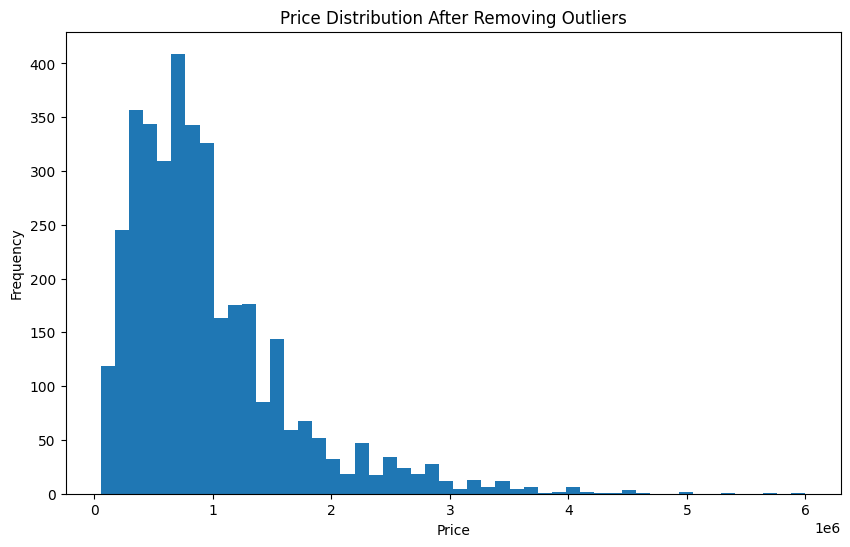

In [273]:
# Show the price distribution after removing outliers
plt.figure(figsize=(10, 6))
plt.hist(df_clean['price'], bins=50)
plt.title('Price Distribution After Removing Outliers')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

In [274]:
# Box plot 
def boxplot(df_func,col):
    plt.figure(figsize=(8, 6))
    sns.boxplot(x=df_func[col])
    plt.title(col+' Box Plot')
    plt.xlabel('Number of '+col)
    plt.show()

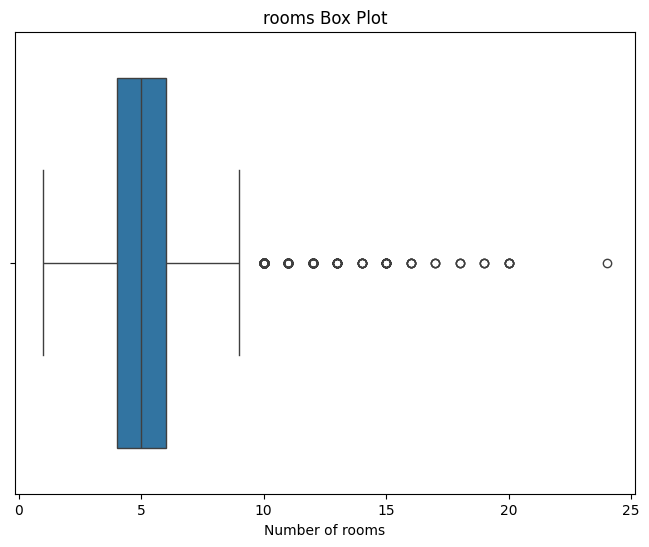

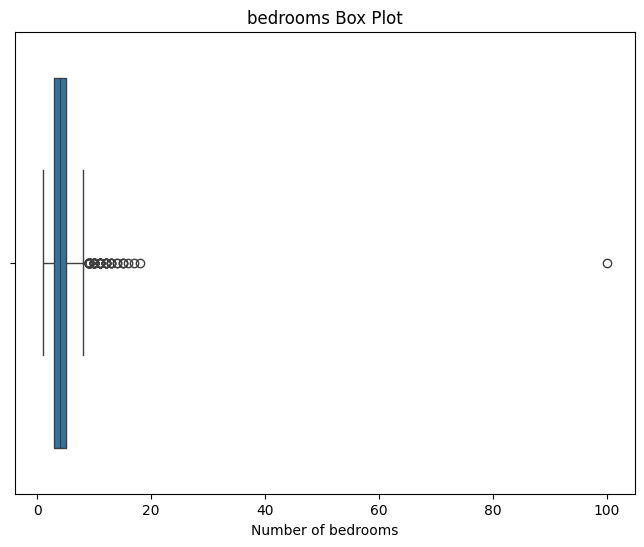

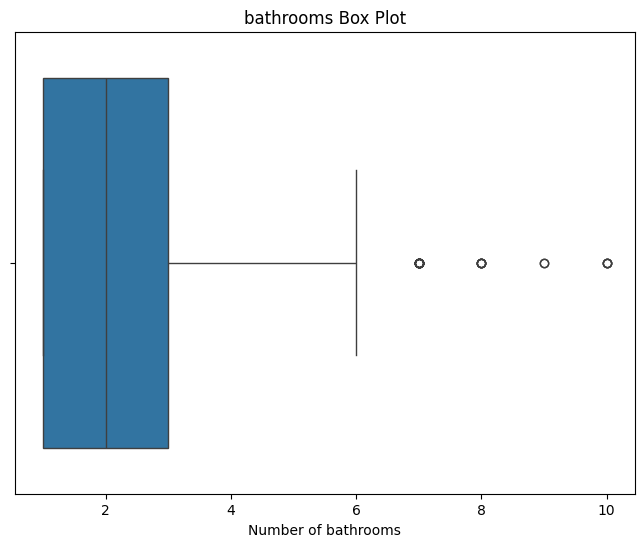

In [275]:
boxplot(df_clean,'rooms') 
boxplot(df_clean,'bedrooms')
boxplot(df_clean,'bathrooms')

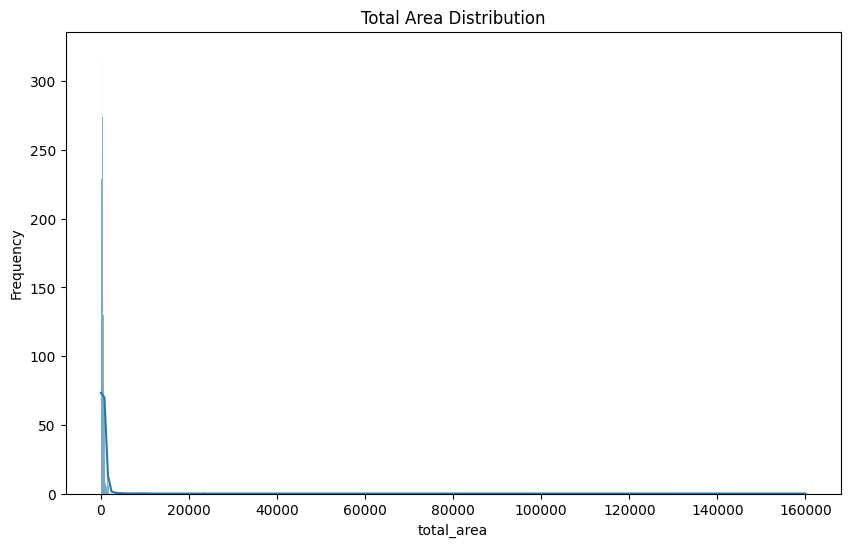

In [276]:

plot_distribution(df_clean['total_area'],'Total Area Distribution','total_area')


In [277]:

print(df_clean.shape)
# Method 1: IQR (Interquartile Range) method
def remove_outliers_iqr(df, column, k=1.5):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - k * iqr
    upper_bound = q3 + k * iqr
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
# Try the IQR method
for col in ["total_area"]:
    df_clean = remove_outliers_iqr(df_clean, col)
    print(f"After IQR outlier removal on {col}: {df_clean.shape}")



(3671, 18)
After IQR outlier removal on total_area: (3417, 18)


In [278]:
def remove_outliers_zscore(df, column, threshold=3):
    # Calculate the Z-score for each data point
    mean = df[column].mean()
    std = df[column].std()
    z_scores = (df[column] - mean) / std
    # Filter out the outliers
    return df[np.abs(z_scores) < threshold]

In [279]:

print(df_clean.shape)
for col in ['bedrooms','rooms','bathrooms']:
    df_clean=remove_outliers_zscore(df_clean,col)
    print(df_clean.shape)


(3417, 18)
(3400, 18)
(3354, 18)
(3336, 18)


## 4-Data visualization

<Axes: xlabel='price', ylabel='total_area'>

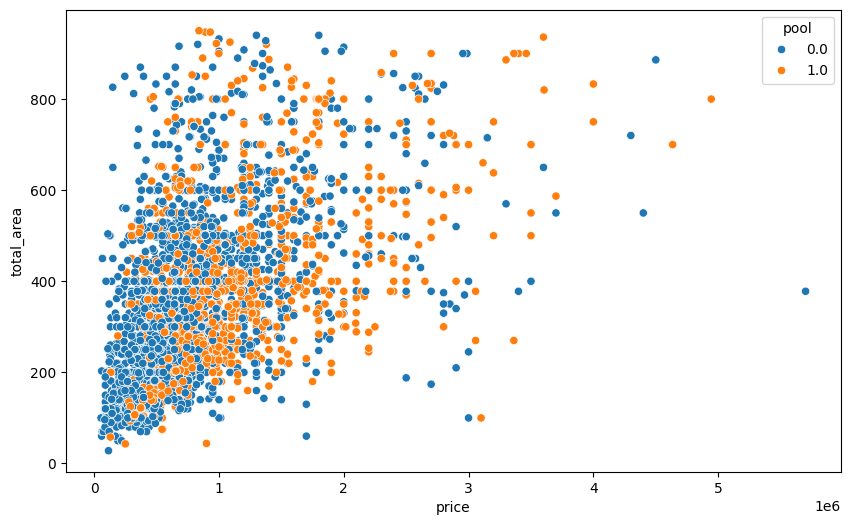

In [280]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_clean['price'], y=df_clean['total_area'],hue=df_clean['pool'])

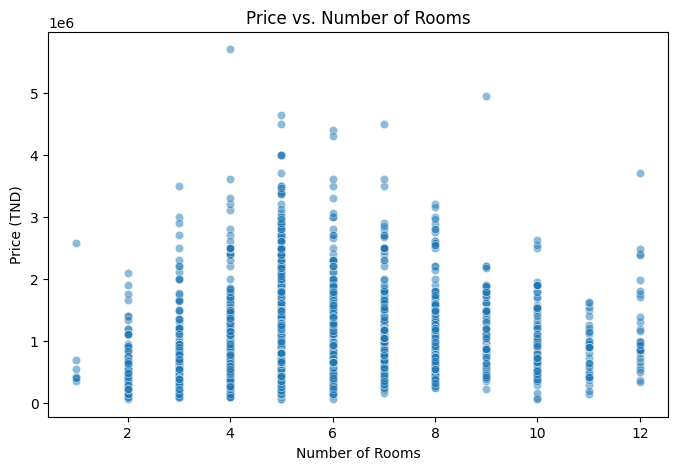

In [281]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='rooms', y='price', data=df_clean, alpha=0.5)
plt.title('Price vs. Number of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Price (TND)')
plt.show()

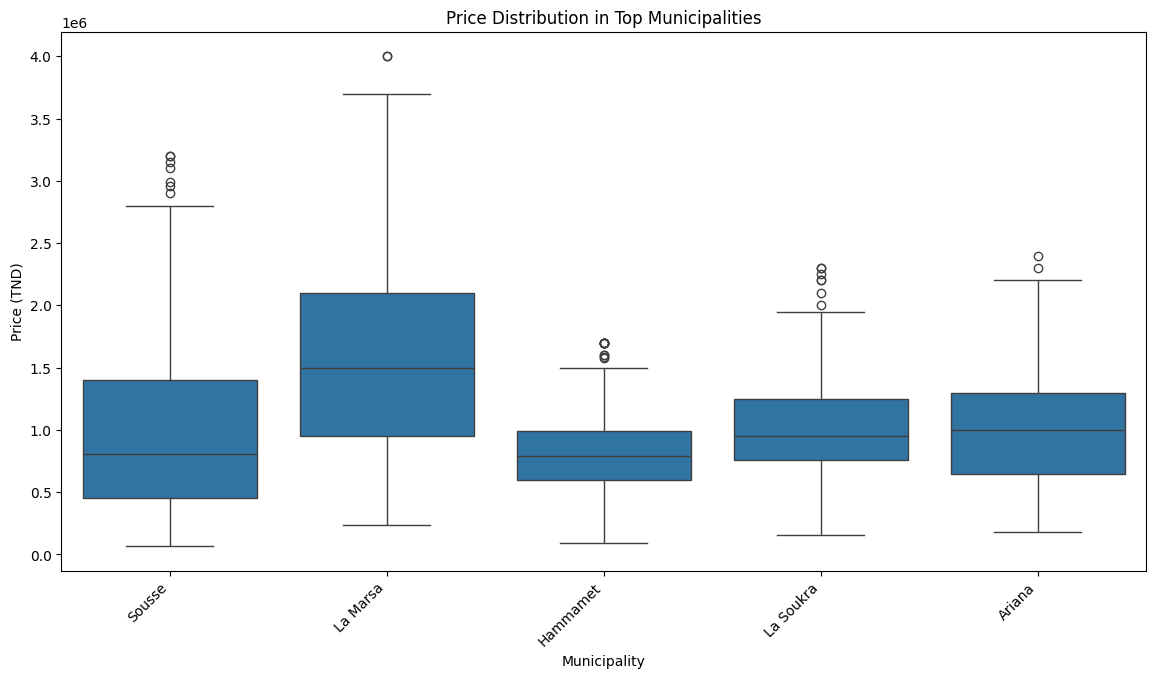

In [282]:
top_municipalities = df_clean.groupby('municipality')['price'].count().sort_values(ascending=False)
top_municipalities = top_municipalities[top_municipalities > 20].index[:5]
plt.figure(figsize=(14, 7))
sns.boxplot(x='municipality', y='price', 
            data=df_clean[df_clean['municipality'].isin(top_municipalities)])
plt.title('Price Distribution in Top Municipalities')
plt.xlabel('Municipality')
plt.ylabel('Price (TND)')
plt.xticks(rotation=45, ha='right')
plt.show()

In [283]:
def count_figure(col):
    plt.figure(figsize=(7, 5))
    sns.countplot(data=df_clean, x=col, palette='deep')
    plt.title('Distribution of Apartments by '+col)
    plt.ylabel('Number of Apartments')
    plt.tight_layout()
    plt.show()

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


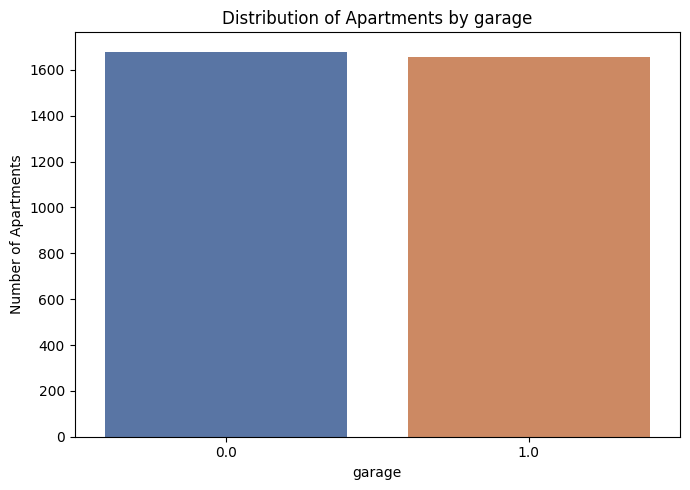

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


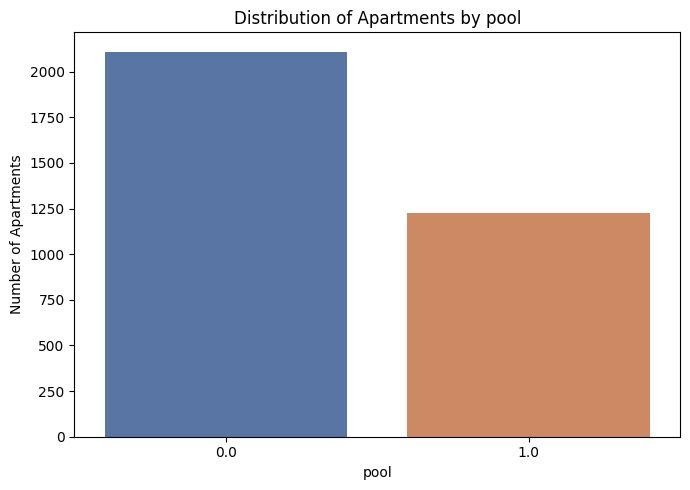

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


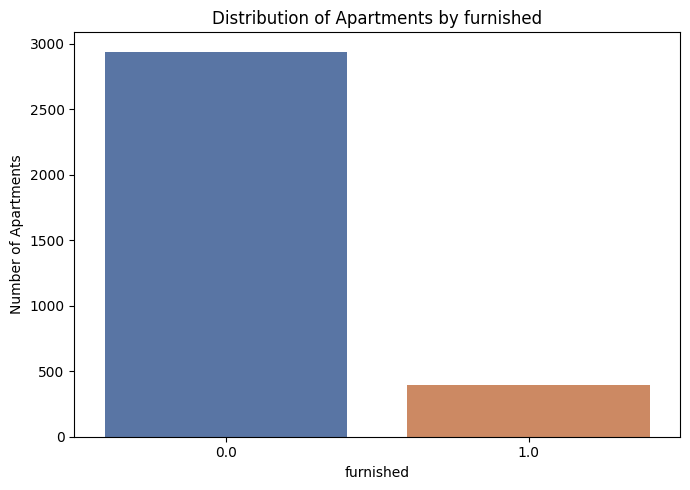

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


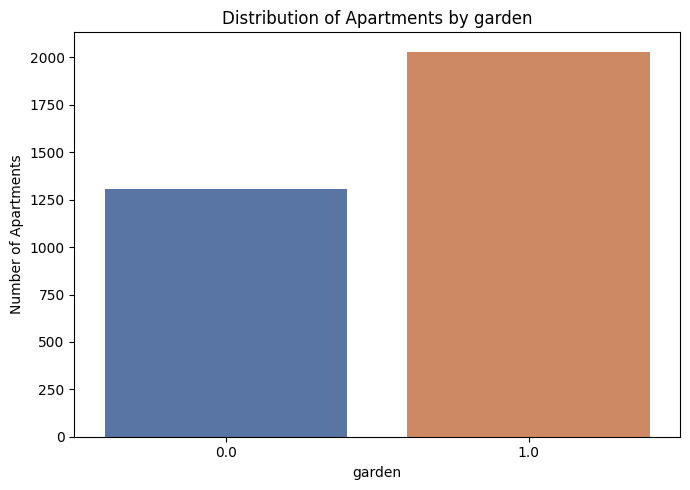

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


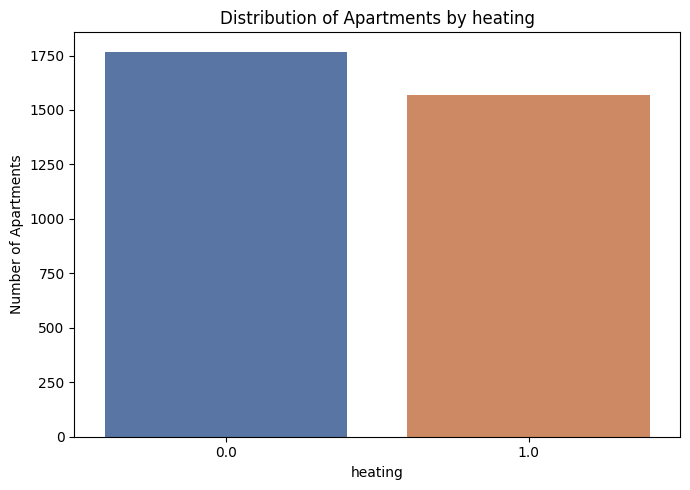

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


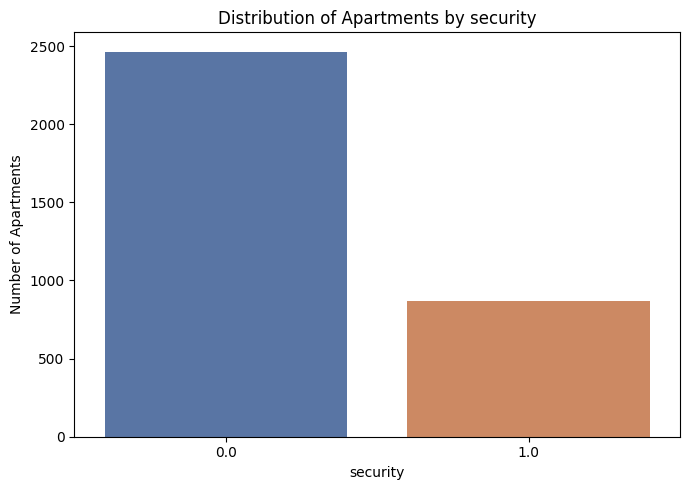

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


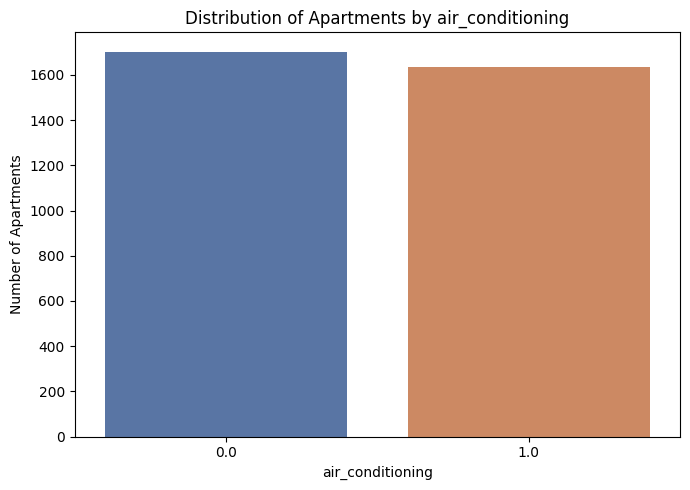

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\3867222634.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x=col, palette='deep')


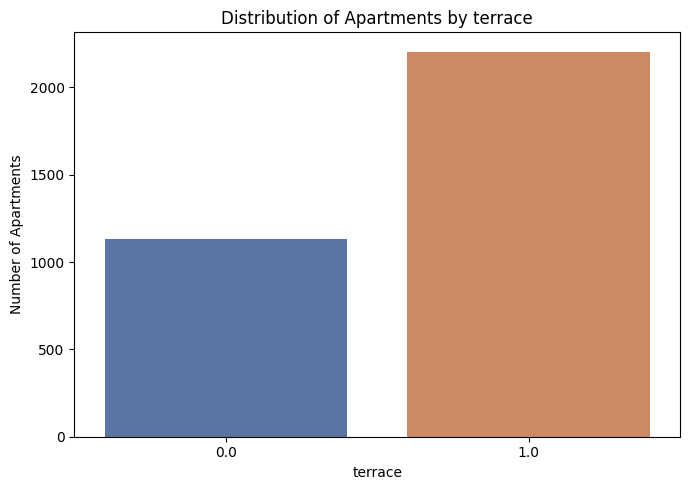

In [284]:
for col in ['garage','pool','furnished','garden','heating','security','air_conditioning','terrace']:
    count_figure(col)

## 4-Feature engineering and selection

In [285]:
# Round latitude and longitude to 4 decimal places
df_clean['latitude'] = df_clean['latitude'].round(4)
df_clean['longitude'] = df_clean['longitude'].round(4)
# Check the rounded values
print(df_clean[['latitude', 'longitude']].head())

   latitude  longitude
1   36.8452    10.1647
2   36.8452    10.1647
3   36.8452    10.1647
4   36.8452    10.1647
5   36.8452    10.1647


In [286]:
df_clean.groupby('municipality')['price'].describe()

,count,mean,std,min,25%,50%,75%,max
municipality,,,,,,,,
Ajim (Djerba),157.0,5.566743e+05,210317.781029,220000.00,394740.000,502300.0,689800.00,1148560.00
Akouda,40.0,8.505983e+05,627359.955186,60000.00,529151.675,680000.0,1121720.06,3362829.60
Al-Qayrawan,3.0,2.816667e+05,127115.433104,135000.00,242500.000,350000.0,355000.00,360000.00
Ariana,173.0,1.034743e+06,504028.701480,180000.00,643000.000,1000000.0,1300000.00,2400000.00
Aïn Draham,2.0,1.225000e+05,38890.872965,95000.00,108750.000,122500.0,136250.00,150000.00
...,...,...,...,...,...,...,...,...
Zaghouan,5.0,5.825132e+05,255116.085869,300000.00,390000.000,600000.0,672565.92,950000.00
Zaouiet Sousse,1.0,1.978145e+05,NaN,197814.50,197814.500,197814.5,197814.50,197814.50
Zarzis,2.0,2.055800e+06,56285.699782,2016000.00,2035900.000,2055800.0,2075700.00,2095600.00


In [287]:
# Calculate average price per municipality
municipality_avg_price = df_clean.groupby('municipality')['price'].mean().reset_index()
municipality_avg_price.columns = ['municipality', 'municipality_avg_price']
# Calculate average price per governorate
governorate_avg_price = df_clean.groupby('governorate')['price'].mean().reset_index()
governorate_avg_price.columns = ['governorate', 'governorate_avg_price']
df_clean = pd.merge(df_clean, municipality_avg_price, on='municipality', how='left')
df_clean = pd.merge(df_clean, governorate_avg_price, on='governorate', how='left')
df_clean.head()

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,latitude,longitude,bedrooms,garage,garden,pool,municipality,governorate,municipality_avg_price,governorate_avg_price
0,2200000.0,Mutuelle Ville à El Menzah,700.0,5.0,1.0,1.0,0.0,1.0,1.0,0.0,36.8452,10.1647,3.0,1.0,1.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194
1,1190000.0,Mutuelle Ville à El Menzah,300.0,4.0,2.0,1.0,1.0,1.0,1.0,0.0,36.8452,10.1647,3.0,1.0,1.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194
2,1845000.0,Mutuelle Ville à El Menzah,586.0,7.0,2.0,1.0,1.0,0.0,1.0,0.0,36.8452,10.1647,6.0,1.0,1.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194
3,1850000.0,Mutuelle Ville à El Menzah,450.0,6.0,2.0,0.0,1.0,1.0,1.0,0.0,36.8452,10.1647,5.0,1.0,1.0,1.0,El Menzah 6,Ariana,1.745667e+06,946091.597194
4,1300000.0,Mutuelle Ville à El Menzah,191.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,36.8452,10.1647,3.0,0.0,0.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194


In [288]:
def generate_quality(col):
    # Create municipality quality feature based on average prices
    # Group by municipality and calculate statistics
    stats = df_clean.groupby(col).agg({
        'price': ['mean', 'median', 'count']
    }).reset_index()

    # Flatten the multi-index columns
    stats.columns = [col, 'avg_price', 'median_price', 'property_count']

    # Separate reliable and unreliable
    min_samples = 3  # Minimum number of properties to consider reliable
    reliable = stats[stats['property_count'] >= min_samples]
    unreliable = stats[stats['property_count'] < min_samples]

    # Create quality tiers for reliable 
    if len(reliable) > 0:
        # Calculate price thresholds from reliable data
        low_threshold = reliable['avg_price'].quantile(0.33)
        high_threshold = reliable['avg_price'].quantile(0.67)
        
        # Create quality tiers using calculated thresholds
        reliable['price_tier'] = pd.cut(
            reliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['affordable_housing_area','mid_price_housing_area', 'premium_housing_area']
        )
        reliable['confidence'] = 'high'
    if len(unreliable) > 0:
        # Apply the same thresholds to unreliable municipalities
        unreliable['price_tier'] = pd.cut(
            unreliable['avg_price'],
            bins=[0, low_threshold, high_threshold, float('inf')],
            labels=['affordable_housing_area','mid_price_housing_area', 'premium_housing_area']
        )
        unreliable['confidence'] = 'low'
        
    # Combine all municipalities
    all_municipalities = pd.concat([reliable, unreliable]) 
    # Create mapping dictionaries
    quality_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['price_tier']
    ))
        
    confidence_map = dict(zip(
        all_municipalities[col], 
        all_municipalities['confidence']
    ))
    return quality_map,confidence_map


In [289]:
# Apply the mappings to create new features
municipality_quality_map_mun,municipality_confidence_map_mun=generate_quality('municipality')
df_clean['municipality_quality'] = df_clean['municipality'].map(municipality_quality_map_mun)
df_clean['municipality_quality_confidence'] = df_clean['municipality'].map(municipality_confidence_map_mun)

municipality_quality_map_gov,municipality_confidence_map_gov=generate_quality('governorate')
df_clean['governorate_quality'] = df_clean['governorate'].map(municipality_quality_map_gov)
df_clean['governorate_quality_confidence'] = df_clean['governorate'].map(municipality_confidence_map_gov)


df_clean.head()

C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\2731654081.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['price_tier'] = pd.cut(
C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\2731654081.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  reliable['confidence'] = 'high'
C:\Users\MSI\AppData\Local\Temp\ipykernel_11764\2731654081.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

,price,address,total_area,rooms,bathrooms,terrace,furnished,air_conditioning,heating,security,...,garden,pool,municipality,governorate,municipality_avg_price,governorate_avg_price,municipality_quality,municipality_quality_confidence,governorate_quality,governorate_quality_confidence
0,2200000.0,Mutuelle Ville à El Menzah,700.0,5.0,1.0,1.0,0.0,1.0,1.0,0.0,...,1.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194,premium_housing_area,high,premium_housing_area,high
1,1190000.0,Mutuelle Ville à El Menzah,300.0,4.0,2.0,1.0,1.0,1.0,1.0,0.0,...,1.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194,premium_housing_area,high,premium_housing_area,high
2,1845000.0,Mutuelle Ville à El Menzah,586.0,7.0,2.0,1.0,1.0,0.0,1.0,0.0,...,1.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194,premium_housing_area,high,premium_housing_area,high
3,1850000.0,Mutuelle Ville à El Menzah,450.0,6.0,2.0,0.0,1.0,1.0,1.0,0.0,...,1.0,1.0,El Menzah 6,Ariana,1.745667e+06,946091.597194,premium_housing_area,high,premium_housing_area,high
4,1300000.0,Mutuelle Ville à El Menzah,191.0,4.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,El Menzah 6,Ariana,1.745667e+06,946091.597194,premium_housing_area,high,premium_housing_area,high


In [290]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3336 entries, 0 to 3335
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   price                            3336 non-null   float64
 1   address                          3336 non-null   object 
 2   total_area                       3336 non-null   float64
 3   rooms                            3336 non-null   float64
 4   bathrooms                        3336 non-null   float64
 5   terrace                          3336 non-null   float64
 6   furnished                        3336 non-null   float64
 7   air_conditioning                 3336 non-null   float64
 8   heating                          3336 non-null   float64
 9   security                         3336 non-null   float64
 10  latitude                         3336 non-null   float64
 11  longitude                        3336 non-null   float64
 12  bedrooms            

### Encoding

In [291]:
"""
mdf = df_clean.groupby('municipality').agg({
    'governorate': 'first',
    'municipality_avg_price': 'mean',
    'governorate_avg_price': 'mean',
    'municipality_quality': 'first',
    'municipality_quality_confidence': 'first',
    'governorate_quality': 'first',
    'governorate_quality_confidence': 'first'
})
mdf.to_csv('municipality_governorate_description.csv')
"""

"\nmdf = df_clean.groupby('municipality').agg({\n    'governorate': 'first',\n    'municipality_avg_price': 'mean',\n    'governorate_avg_price': 'mean',\n    'municipality_quality': 'first',\n    'municipality_quality_confidence': 'first',\n    'governorate_quality': 'first',\n    'governorate_quality_confidence': 'first'\n})\nmdf.to_csv('municipality_governorate_description.csv')\n"

In [292]:
df_clean.columns

Index(['price', 'address', 'total_area', 'rooms', 'bathrooms', 'terrace',
       'furnished', 'air_conditioning', 'heating', 'security', 'latitude',
       'longitude', 'bedrooms', 'garage', 'garden', 'pool', 'municipality',
       'governorate', 'municipality_avg_price', 'governorate_avg_price',
       'municipality_quality', 'municipality_quality_confidence',
       'governorate_quality', 'governorate_quality_confidence'],
      dtype='object')

In [293]:
# List of categorical columns to convert
categorical_columns = [  'municipality_quality', 'municipality_quality_confidence',
       'governorate_quality', 'governorate_quality_confidence']

# Filter to only include columns that exist in the dataframe
categorical_columns = [col for col in categorical_columns if col in df_clean.columns]

if categorical_columns:
    # Create dummy variables and drop original columns
    df_clean = pd.get_dummies(df_clean, columns=categorical_columns, drop_first=False)
else:
    print("No categorical columns found in the dataframe")

In [294]:
df_clean=df_clean.drop(columns=['municipality','governorate','address'],axis=1)

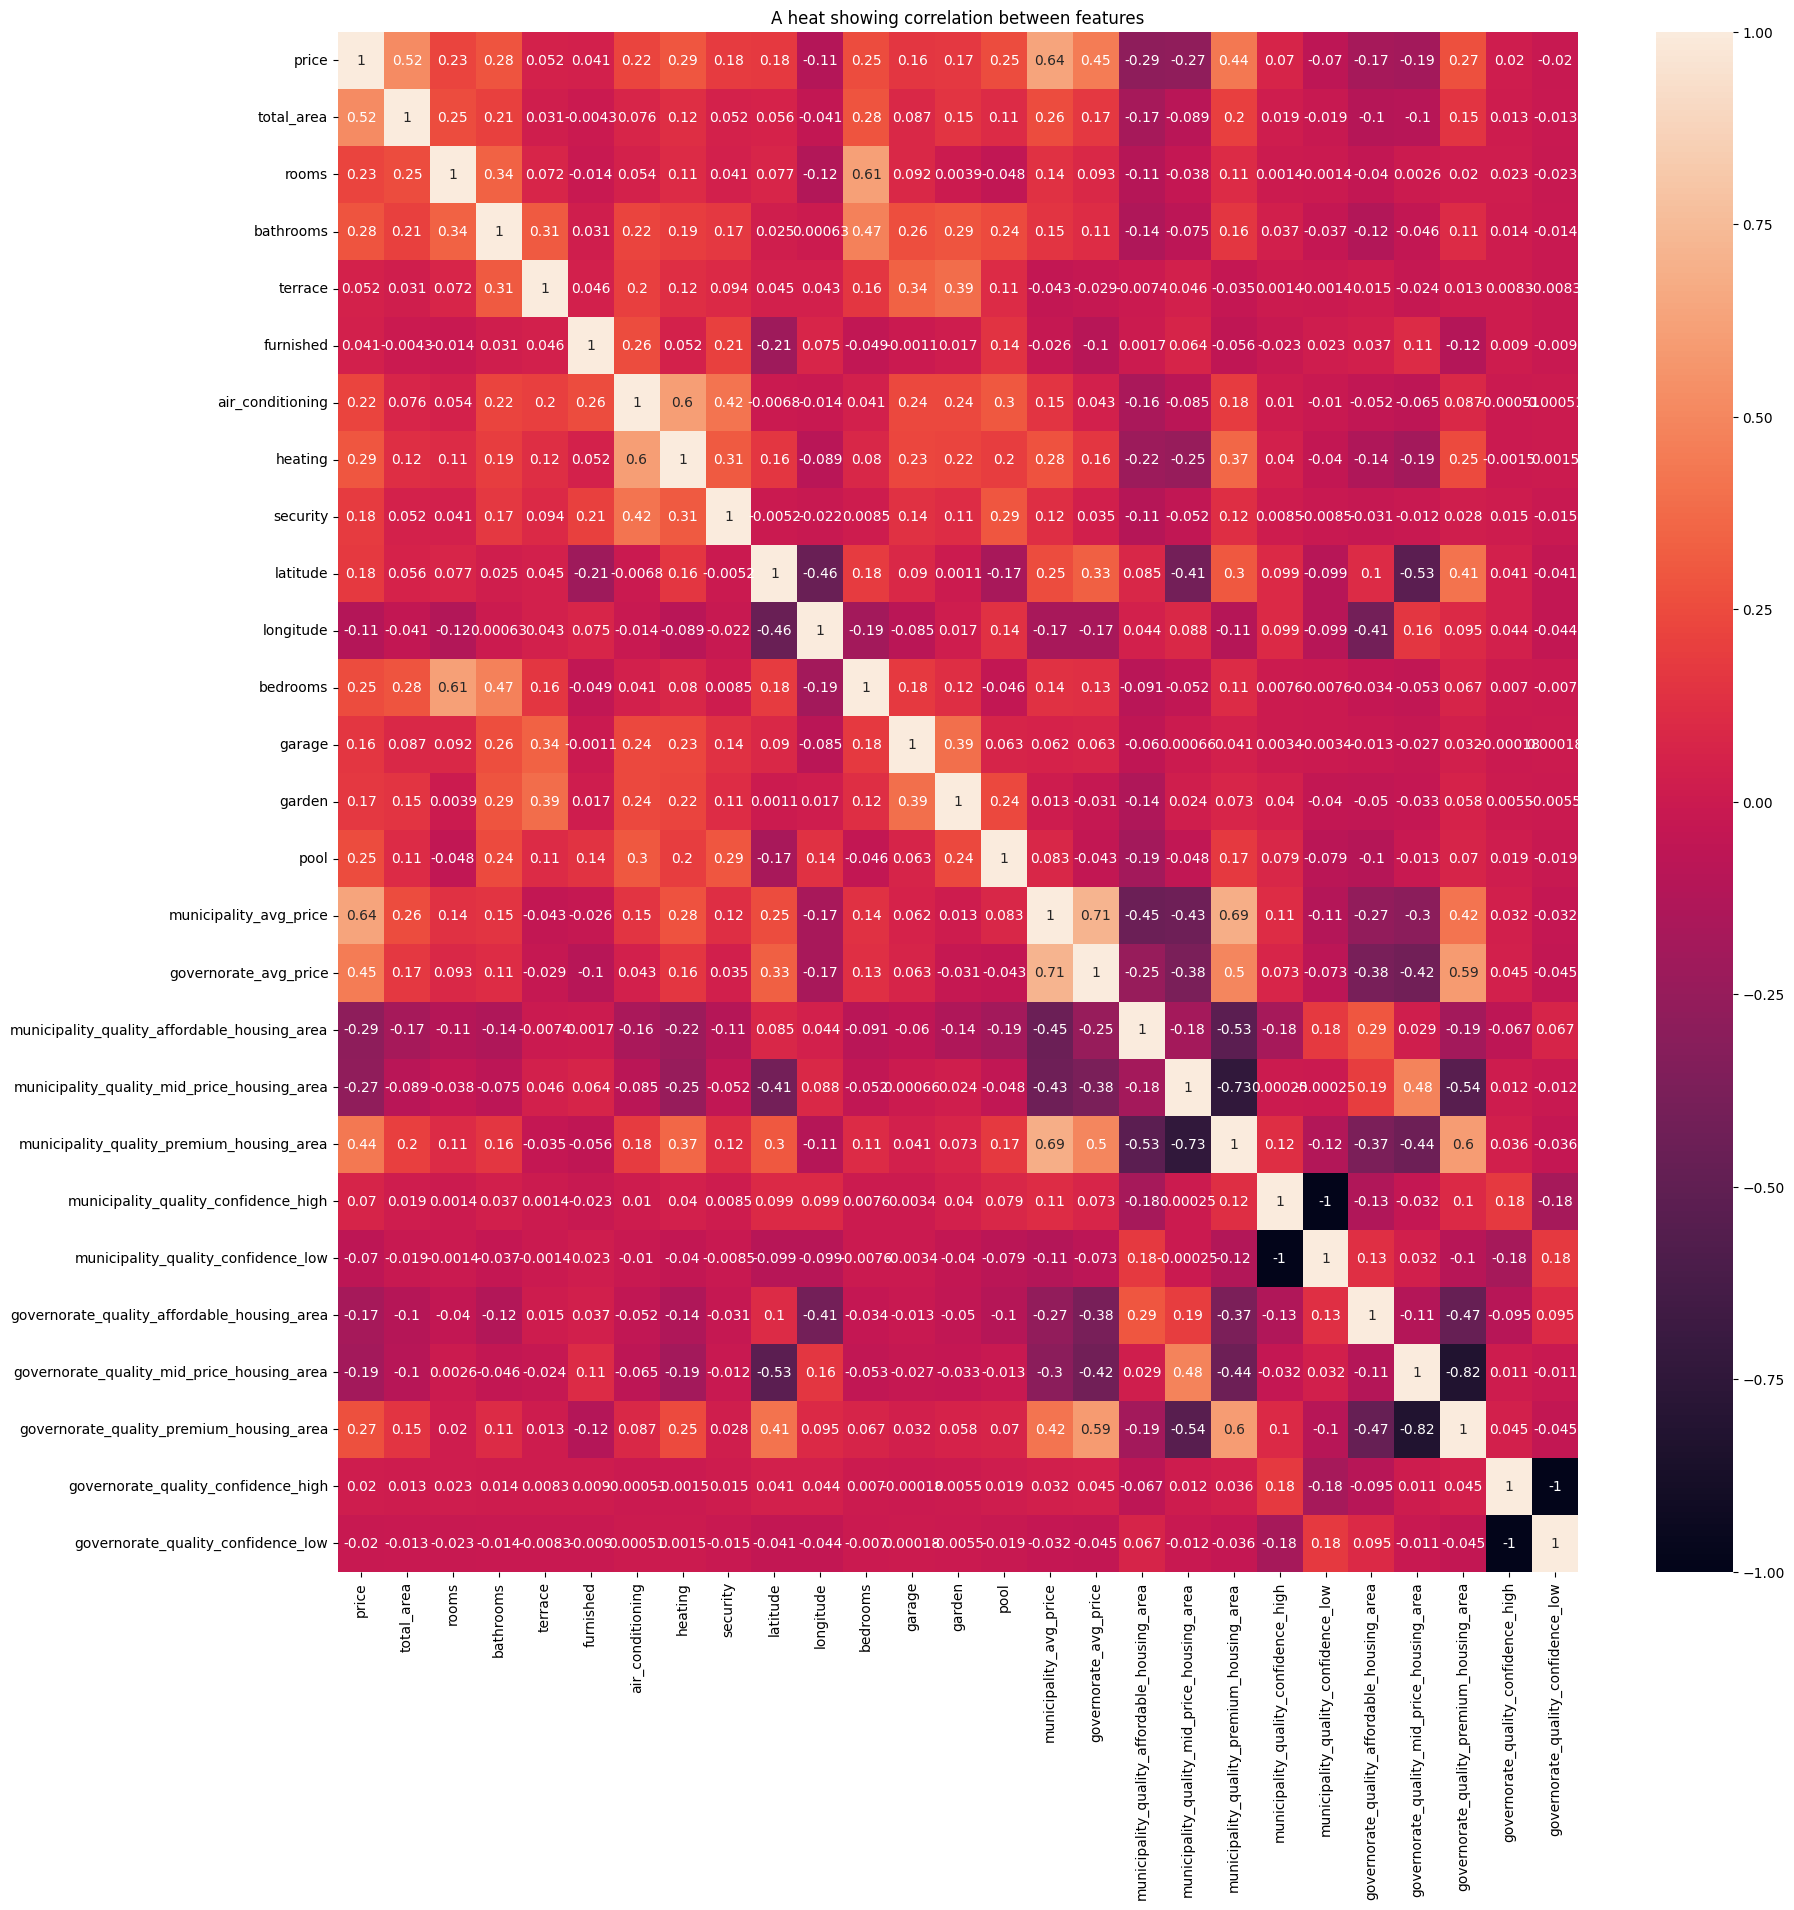

In [295]:
plt.figure(figsize=(20, 20))
sns.heatmap(df_clean.corr(), annot=True)
plt.title("A heat showing correlation between features")
plt.show()


In [ ]:
#df_clean.to_csv('clean_home_data.csv',index=False)

In [317]:
df_syn=pd.read_csv('house_buying_synthatic.csv')
df_syn=df_syn.dropna()
df_syn.shape

(4141, 27)

In [319]:
df=pd.concat([df_clean,df_syn])
df.shape

(7477, 27)

## Modeling

In [321]:
X=df.drop(columns=['price'],axis=1)
y=df['price']
print(X.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

(7477, 26)


In [127]:
X.columns

Index(['total_area', 'rooms', 'bathrooms', 'terrace', 'furnished',
       'air_conditioning', 'heating', 'security', 'latitude', 'longitude',
       'bedrooms', 'garage', 'garden', 'pool', 'municipality_avg_price',
       'governorate_avg_price', 'municipality_quality_affordable_housing_area',
       'municipality_quality_mid_price_housing_area',
       'municipality_quality_premium_housing_area',
       'municipality_quality_confidence_high',
       'municipality_quality_confidence_low',
       'governorate_quality_affordable_housing_area',
       'governorate_quality_mid_price_housing_area',
       'governorate_quality_premium_housing_area',
       'governorate_quality_confidence_high',
       'governorate_quality_confidence_low'],
      dtype='object')

In [128]:
X.iloc[0,:]

total_area                                               405.0
rooms                                                      5.0
bathrooms                                                  5.0
terrace                                                    0.0
furnished                                                  0.0
air_conditioning                                           0.0
heating                                                    0.0
security                                                   0.0
latitude                                               36.8764
longitude                                              10.3253
bedrooms                                                   4.0
garage                                                     0.0
garden                                                     0.0
pool                                                       0.0
municipality_avg_price                          1578293.397095
governorate_avg_price                           1449446

In [301]:
# Define the function to evaluate model performance
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    
    
    print("\nModel: ",model_name)
    print(f"Training R²: {train_r2:.4f}, Test R²: {test_r2:.4f}")
    print(f"Training MAE: {train_mae:.2f}, Test MAE: {test_mae:.2f}")
    print(f"R² Difference (Overfitting): {train_r2 - test_r2:.4f}")

In [302]:
def cross_val_evaluate(model):
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    print(f"\nCross-validation R² scores: {cv_scores}")
    print(f"Mean CV R² score: {np.mean(cv_scores):.4f}")
    print(f"Standard deviation of CV R² scores: {np.std(cv_scores):.4f}")

    # Get feature importances
    feature_importances = model.feature_importances_
    features = X_train.columns
    importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
    importance_df = importance_df.sort_values('Importance', ascending=False).head(15)
    # Plot
    plt.figure(figsize=(12, 8))
    plt.barh(importance_df['Feature'], importance_df['Importance'])
    plt.xlabel('Importance')
    plt.title('Top 15 Feature Importances')
    plt.gca().invert_yaxis()  # Display the most important feature at the top
    plt.tight_layout()
    plt.show()

#### Linear Regression

In [322]:
lr=LinearRegression()
evaluate_model(lr, X_train, X_test, y_train, y_test,"Linear Regression")


Model:  Linear Regression
Training R²: 0.6719, Test R²: 0.6542
Training MAE: 184154.91, Test MAE: 195784.69
R² Difference (Overfitting): 0.0176


### Decision Tree Regressor

Starting hyperparameter search for Decision Tree...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 0.7, 'max_depth': 10}

Model:  Decision Tree
Training R²: 0.7958, Test R²: 0.6963
Training MAE: 136651.08, Test MAE: 173928.38
R² Difference (Overfitting): 0.0995

Cross-validation R² scores: [0.6846525  0.69348596 0.65988318 0.60843396 0.65920007]
Mean CV R² score: 0.6611
Standard deviation of CV R² scores: 0.0296


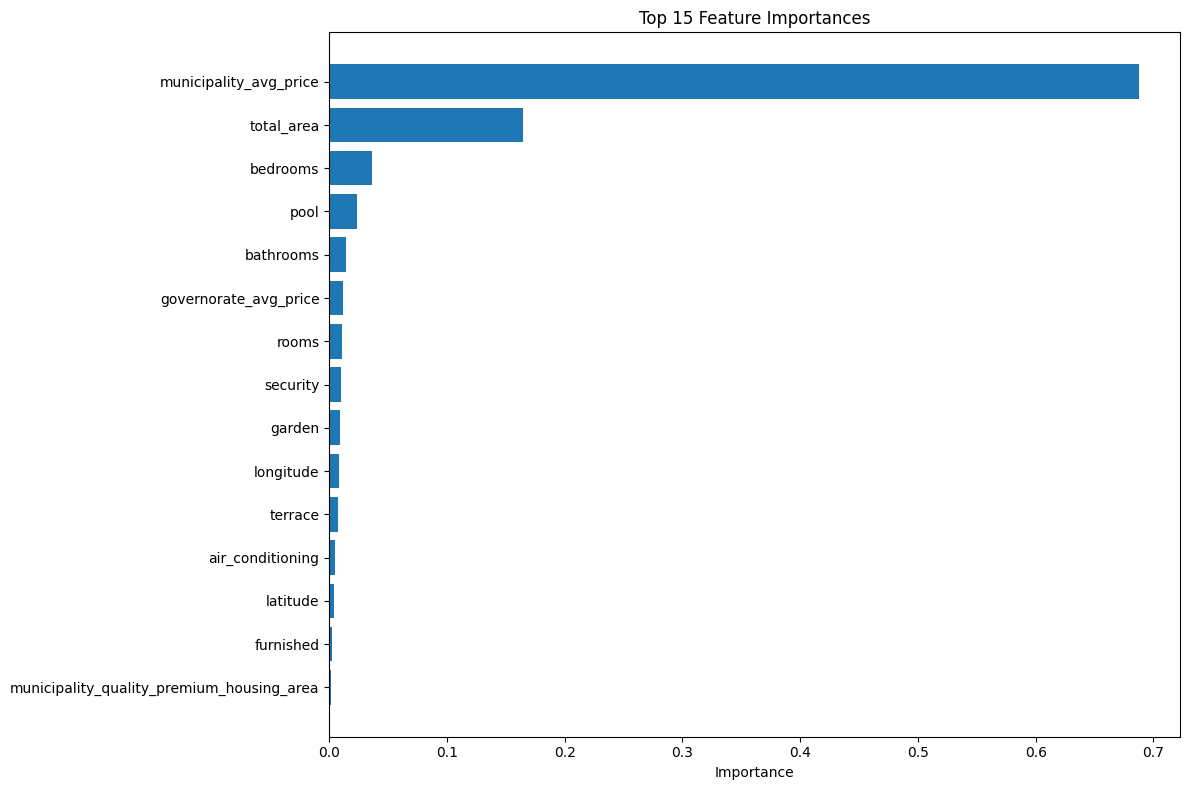

In [323]:
# Define the parameter distribution for Decision Tree
param_dist = {
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of the tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7]  # Number of features to consider when looking for the best split
}
# Create a base Decision Tree model
dt = DecisionTreeRegressor(random_state=42)
# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)
# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
dt_random = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)
# Fit RandomizedSearchCV
print("Starting hyperparameter search for Decision Tree...")
dt_random.fit(X_train, y_train)
print("Hyperparameter search completed!")
# Get the best parameters and score
print(f"Best parameters: {dt_random.best_params_}")
# Create a model with the best parameters
best_dt = DecisionTreeRegressor(**dt_random.best_params_, random_state=42)
evaluate_model(best_dt, X_train, X_test, y_train, y_test, "Decision Tree")
cross_val_evaluate(best_dt)

### Random forest

Starting hyperparameter search...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'oob_score': True, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_samples': 0.7, 'max_features': 0.7, 'max_depth': 15, 'bootstrap': True}

Model:  Random forest
Training R²: 0.8935, Test R²: 0.7522
Training MAE: 94978.72, Test MAE: 153271.34
R² Difference (Overfitting): 0.1413

Cross-validation R² scores: [0.76042236 0.74375151 0.73788821 0.7443587  0.75196388]
Mean CV R² score: 0.7477
Standard deviation of CV R² scores: 0.0078


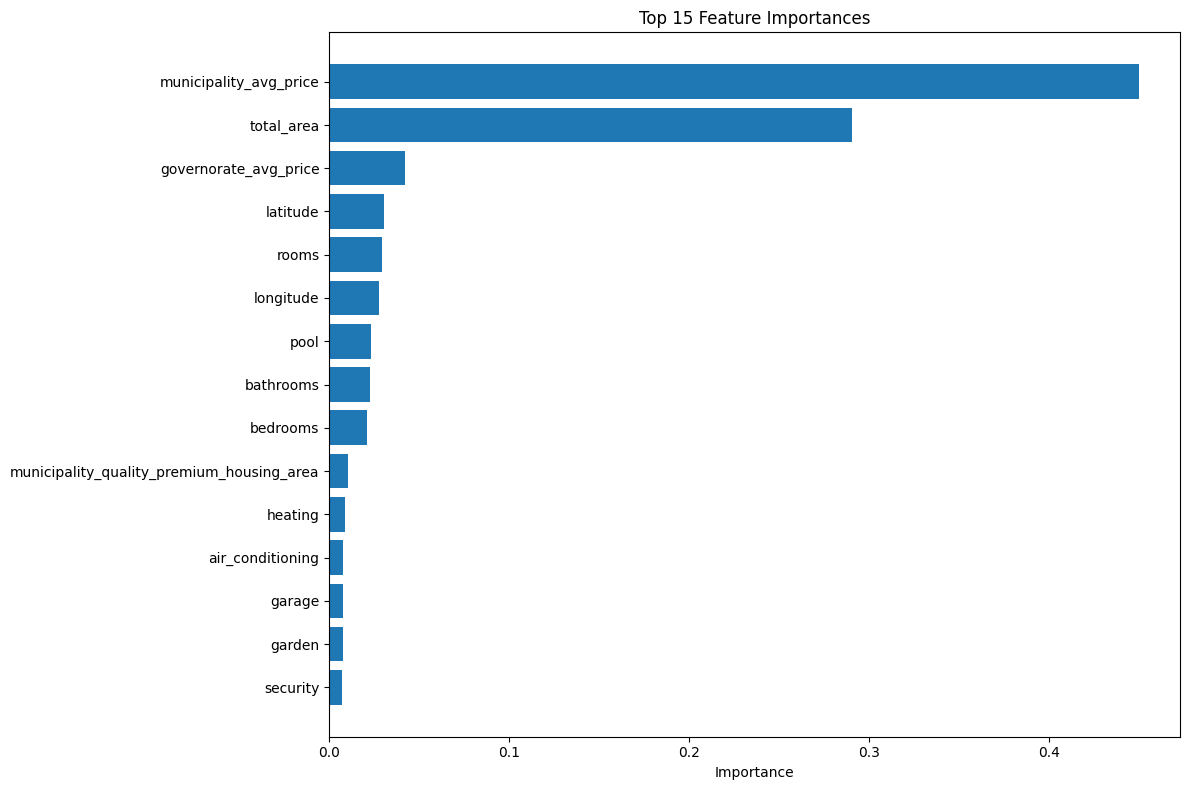

In [324]:
# Define the parameter distribution with more regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of trees in the forest
    'max_depth': [5, 6, 7, 8, 10, 15, None],  # Maximum depth of each tree
    'min_samples_split': [5, 10, 15, 20, 25],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [2, 4, 6, 8, 10],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],  # Number of features to consider when looking for the best split
    'bootstrap': [True],  # Whether bootstrap samples are used when building trees
    'oob_score': [True],  # Whether to use out-of-bag samples to estimate the generalization error
    'max_samples': [0.7, 0.8, 0.9, None]  # Fraction of samples to draw from X to train each base estimator
}

# Create a base Random Forest model
rf = RandomForestRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
rf_random = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,   # Controls the verbosity of the output
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_absolute_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search...")
rf_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {rf_random.best_params_}")

# Create a model with the best parameters
best_rf = RandomForestRegressor(**rf_random.best_params_, random_state=42)
evaluate_model(best_rf, X_train, X_test, y_train, y_test, "Random forest")
cross_val_evaluate(best_rf)

### GradientBoostingRegressor

Starting hyperparameter search for Gradient Boosting...
Fitting 5 folds for each of 100 candidates, totalling 500 fits
Hyperparameter search completed!
Best parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 6, 'learning_rate': 0.05, 'alpha': 0.5}
Best cross-validation MSE: 65197131294.87

Model:  Gradient boost regressor
Training R²: 0.8574, Test R²: 0.7482
Training MAE: 119972.95, Test MAE: 156320.36
R² Difference (Overfitting): 0.1092

Cross-validation R² scores: [0.75900432 0.74402149 0.74998578 0.74373169 0.75066401]
Mean CV R² score: 0.7495
Standard deviation of CV R² scores: 0.0056


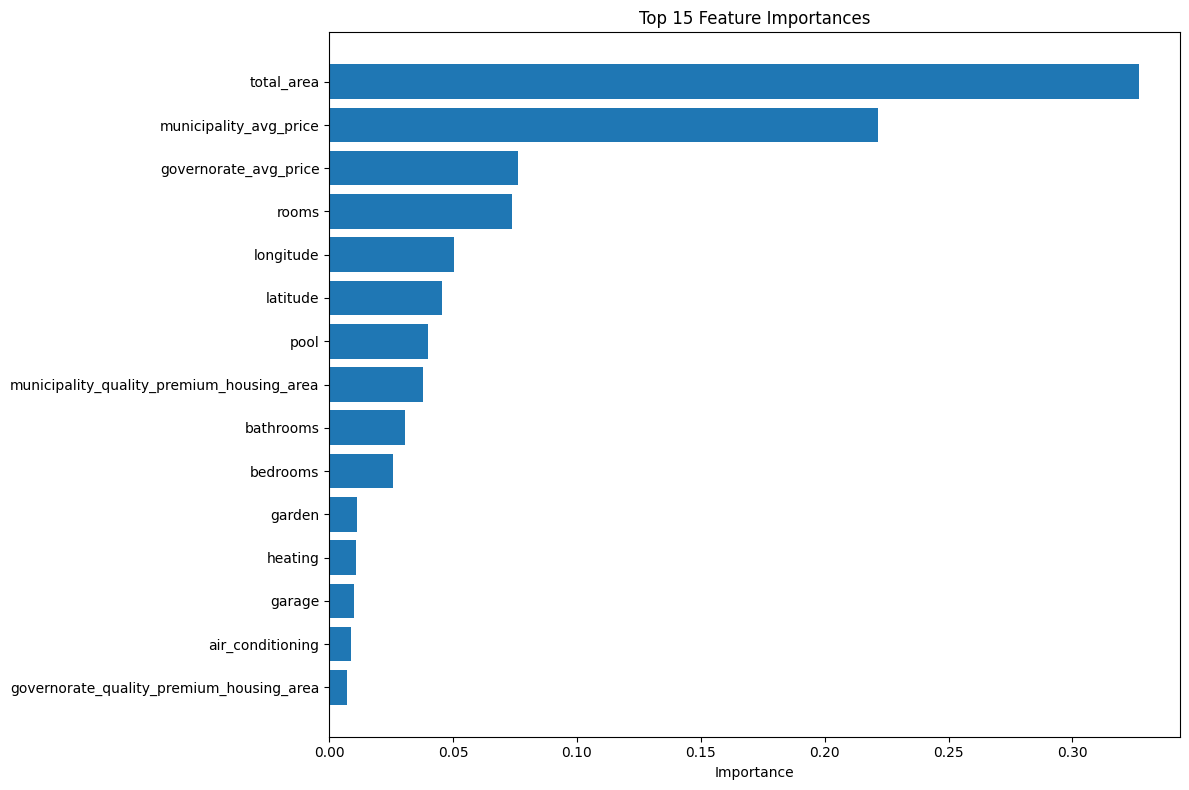

In [325]:
from sklearn.ensemble import GradientBoostingRegressor
# Define the parameter distribution with regularization options
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],  # Number of boosting stages to be run
    'learning_rate': [0.01, 0.05, 0.1, 0.15, 0.2],  # Step size shrinkage used in update to prevent overfitting
    'max_depth': [3, 4, 5, 6, 8],  # Maximum depth of the individual regression estimators
    'min_samples_split': [2, 5, 10, 15, 20],  # Minimum number of samples required to split an internal node
    'min_samples_leaf': [1, 2, 4, 6, 8],  # Minimum number of samples required to be at a leaf node
    'max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],  # Number of features to consider when looking for the best split
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],  # Fraction of samples used for fitting the individual base learners
    'alpha': [0.1, 0.5, 0.9]  # The alpha-quantile of the huber loss function and the quantile loss function
}

# Create a base Gradient Boosting model
sgb = GradientBoostingRegressor(random_state=42)

# Create a cross-validation strategy
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Set up RandomizedSearchCV with a scoring metric that penalizes complexity
sgb_random = RandomizedSearchCV(
    estimator=sgb,
    param_distributions=param_dist,
    n_iter=100,  # Number of parameter settings sampled
    cv=cv,       # 5-fold cross-validation with shuffling
    verbose=2,
    random_state=42,
    n_jobs=-1,   # Use all available cores
    scoring='neg_mean_squared_error'  # Focus on error minimization
)

# Fit RandomizedSearchCV
print("Starting hyperparameter search for Gradient Boosting...")
sgb_random.fit(X_train, y_train)
print("Hyperparameter search completed!")

# Get the best parameters and score
print(f"Best parameters: {sgb_random.best_params_}")
print(f"Best cross-validation MSE: {-sgb_random.best_score_:.2f}")
# Create a model with the best parameters
best_sgb = GradientBoostingRegressor(**sgb_random.best_params_, random_state=42)
evaluate_model(best_sgb, X_train, X_test, y_train, y_test,"Gradient boost regressor")
cross_val_evaluate(best_sgb)

In [ ]:
import pickle
with open('house_buying_full.pkl','wb') as file:
    pickle.dump(best_sgb,file)

"\nimport pickle\nwith open('house_buying_half.pkl','wb') as file:\n    pickle.dump(voting_ensemble,file)\n"